In [1]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from matplotlib.figure import Figure
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
import seaborn as sns
import colorcet as cc
from sklearn.neighbors import KernelDensity

In [2]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (separate runs)
        idate = start_dates[ii]
        idirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(idirs) > 0:
            for dd in idirs:
                # Find track stats file
                fname = sorted(glob.glob(f'{dd}/{domain}/stats/{in_basename}*nc'))
                if len(fname) > 0:
                    files.append(fname[0])
    return files

In [3]:
# figdir = '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/pyflextrkr_paper/'

# # CSAPR data directory
# dir_obs = '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/csapr/stats4lasso/'
# terrain_file = f'/gpfs/wolf/cli120/proj-shared/zfeng/cacti/csapr/corgridded_terrain.c0/topo_cacti_csapr2_large.nc'
# radar_lat = -32.1264
# radar_lon = -64.7284

# basename_obs = 'csapr_trackstats_'
# files_obs = sorted(glob.glob(f'{dir_obs}{basename_obs}*nc'))
# files_obs

In [4]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
rootdir_m = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'

figdir = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/pyflextrkr_paper/'

# Domain 4 boundaries
lon_range = [-65.4, -63.1]
lat_range = [-33.3, -30.8]
gridspacing_d3 = '500m'
gridspacing_d4 = '100m'

# Find LASSO files
files_d3 = find_lasso_files(start_dates, rootdir_m, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_m, in_basename, 'd4_15min')
wfiles_d3 = find_lasso_files(start_dates, rootdir_m, in_basename_w, 'd3')
wfiles_d4 = find_lasso_files(start_dates, rootdir_m, in_basename_w, 'd4_15min')
files_d3, files_d4, wfiles_d3, wfiles_d4

(['/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181129/gefs03/d3/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181129/gefs00/d3/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181204/gefs19/d3/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181204/gefs18/d3/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181205/gefs01/d3/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20181219/eda09/d3/stats/trackstats_20181219.1200_20181220.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20190122/gefs01/d3/stats/trackstats_20190122.1200_20190123.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//20190123/eda05/d3/stats/trackstats_20190123.1200_20190124.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les//

In [5]:
# Read track data (LASSO D3)
dst_d3 = xr.open_mfdataset(files_d3, concat_dim='tracks', combine='nested').load()
# Renumber tracks to make it continuous
ntracks_d3 = dst_d3.sizes['tracks']
dst_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

# Read W data (LASSO D3)
dsw_d3 = xr.open_mfdataset(wfiles_d3, concat_dim='tracks', combine='nested').load()
# Renumber tracks to make it continuous
dsw_d3['tracks'] = np.arange(0, ntracks_d3)

# Combine 2D and 3D datasets by coordinates
ds_d3 = xr.combine_by_coords([dst_d3, dsw_d3], combine_attrs='drop_conflicts')
ntimes_d3 = ds_d3.sizes['times']
ds_d3

Number of tracks (D3): 7856


<xarray.Dataset>
Dimensions:                  (tracks: 7856, times: 60, z: 29, core: 20)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 7852 7853 7854 7855
  * times                    (times) int64 0 1 2 3 4 5 6 ... 54 55 56 57 58 59
  * z                        (z) float64 500.0 1e+03 1.5e+03 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 ... 13 14 15 16 17 18 19
Data variables: (12/49)
    CoreArea_up              (tracks, times, z, core) float32 nan nan ... nan
    CoreMaxW_up              (tracks, times, z, core) float32 nan nan ... nan
    CoreMeanW_up             (tracks, times, z, core) float32 nan nan ... nan
    CoreMassFlux_up          (tracks, times, z, core) float32 nan nan ... nan
    CoreArea_down            (tracks, times, z, core) float32 nan nan ... nan
    CoreMinW_down            (tracks, times, z, core) float32 nan nan ... nan
    ...                       ...
    start_split_tracknumber  (tracks) float64 nan nan nan ... 385.0 385.0 330.0
    start_split_timeindex    (tracks) float64 nan nan nan nan ... 4.0 4.0 9.0
    start_split_cloudnumber  (tracks) float64 nan nan nan nan ... 1.0 1.0 2.0
    end_merge_tracknumber    (tracks) float64 nan 23.0 6.0 nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 nan 1.0 1.0 nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 nan 2.0 1.0 nan ... nan nan nan
Attributes:
    title:                 Tracked cell W statistics
    Contact:               Zhe Feng, zhe.feng@pnnl.gov
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    Title:                 Statistics of each track
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       0.5

In [ ]:
# Read track data (LASSO D4)
dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested').load()
# Renumber tracks to make it continuous
ntracks_d4 = dst_d4.sizes['tracks']
dst_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (d4): {ntracks_d4}')

# Read W data (LASSO D4)
dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested').load()
# Renumber tracks to make it continuous
dsw_d4['tracks'] = np.arange(0, ntracks_d4)

# Combine 2D and 3D datasets by coordinates
ds_d4 = xr.combine_by_coords([dst_d4, dsw_d4], combine_attrs='drop_conflicts')
# Trim times dimension to match D3
ds_d4 = ds_d4.isel(times=slice(0, ntimes_d3))
ds_d4

Number of tracks (d4): 3130


In [ ]:
ds_d4.isel(times=slice(0, 60))

In [ ]:
# Get track min/max lat/lon
minlon_d3 = ds_d3['meanlon'].min(dim='times')
maxlon_d3 = ds_d3['meanlon'].max(dim='times')
minlat_d3 = ds_d3['meanlat'].min(dim='times')
maxlat_d3 = ds_d3['meanlat'].max(dim='times')
# Subset D3 tracks that are within D4 boundary
ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
                    (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

In [9]:
HAMSL_d3 = ds_d3['z']
time_res_d3 = ds_d3.attrs['time_resolution_hour']
pixel_radius_d3 = ds_d3.attrs['pixel_radius_km']
lifetime_d3 = ds_d3['track_duration'] * time_res_d3

start_time_d3 = ds_d3['start_basetime']
end_time_d3 = ds_d3['end_basetime']
end_merge_tracknumber_d3 = ds_d3['end_merge_tracknumber']
start_split_tracknumber_d3 = ds_d3['start_split_tracknumber']
cell_lon_d3 = ds_d3['cell_meanlon']
cell_lat_d3 = ds_d3['cell_meanlat']
cell_area_d3 = ds_d3['cell_area']
maxrange_flag_d3 = ds_d3['maxrange_flag']
start_lon_d3 = cell_lon_d3.isel(times=0)
start_lat_d3 = cell_lat_d3.isel(times=0)

maxdbz_d3 = ds_d3['max_dbz']
eth10_d3 = ds_d3['maxETH_10dbz']
eth20_d3 = ds_d3['maxETH_20dbz']
eth30_d3 = ds_d3['maxETH_30dbz']
eth40_d3 = ds_d3['maxETH_40dbz']
eth50_d3 = ds_d3['maxETH_50dbz']

In [10]:
HAMSL_d4 = ds_d4['z']
time_res_d4 = ds_d4.attrs['time_resolution_hour']
pixel_radius_d4 = ds_d4.attrs['pixel_radius_km']
lifetime_d4 = ds_d4['track_duration'] * time_res_d4

start_time_d4 = ds_d4['start_basetime']
end_time_d4 = ds_d4['end_basetime']
end_merge_tracknumber_d4 = ds_d4['end_merge_tracknumber']
start_split_tracknumber_d4 = ds_d4['start_split_tracknumber']
cell_lon_d4 = ds_d4['cell_meanlon']
cell_lat_d4 = ds_d4['cell_meanlat']
cell_area_d4 = ds_d4['cell_area']
maxrange_flag_d4 = ds_d4['maxrange_flag']
start_lon_d4 = cell_lon_d4.isel(times=0)
start_lat_d4 = cell_lat_d4.isel(times=0)

maxdbz_d4 = ds_d4['max_dbz']
eth10_d4 = ds_d4['maxETH_10dbz']
eth20_d4 = ds_d4['maxETH_20dbz']
eth30_d4 = ds_d4['maxETH_30dbz']
eth40_d4 = ds_d4['maxETH_40dbz']
eth50_d4 = ds_d4['maxETH_50dbz']

In [11]:
# Find tracks not end with merge or not start with split
nonmerge_d3 = np.where(np.isnan(end_merge_tracknumber_d3))[0]
nonsplit_d3 = np.where(np.isnan(start_split_tracknumber_d3))[0]
ntracks_nonmerge_d3 = len(nonmerge_d3)
ntracks_nonsplit_d3 = len(nonsplit_d3)
print(f'Number of non-merge tracks (D3): {ntracks_nonmerge_d3}')
print(f'Number of non-split tracks (D3): {ntracks_nonsplit_d3}')

merge_d3 = np.where(end_merge_tracknumber_d3 > 0)[0]
split_d3 = np.where(start_split_tracknumber_d3 > 0)[0]
ntracks_merge_d3 = len(merge_d3)
ntracks_split_d3 = len(split_d3)
print(f'Number of merge tracks (D3): {ntracks_merge_d3}')
print(f'Number of split tracks (D3): {ntracks_split_d3}')

Number of non-merge tracks (D3): 1918
Number of non-split tracks (D3): 1891
Number of merge tracks (D3): 1375
Number of split tracks (D3): 1402


In [12]:
# Find tracks not end with merge or not start with split
nonmerge_d4 = np.where(np.isnan(end_merge_tracknumber_d4))[0]
nonsplit_d4 = np.where(np.isnan(start_split_tracknumber_d4))[0]
ntracks_nonmerge_d4 = len(nonmerge_d4)
ntracks_nonsplit_d4 = len(nonsplit_d4)
print(f'Number of non-merge tracks (D4): {ntracks_nonmerge_d4}')
print(f'Number of non-split tracks (D4): {ntracks_nonsplit_d4}')

merge_d4 = np.where(end_merge_tracknumber_d4 > 0)[0]
split_d4 = np.where(start_split_tracknumber_d4 > 0)[0]
ntracks_merge_d4 = len(merge_d4)
ntracks_split_d4 = len(split_d4)
print(f'Number of merge tracks (D4): {ntracks_merge_d4}')
print(f'Number of split tracks (D4): {ntracks_split_d4}')

Number of non-merge tracks (D4): 1830
Number of non-split tracks (D4): 1884
Number of merge tracks (D4): 1225
Number of split tracks (D4): 1171


In [13]:
# def quantiles_by1cond(in_var, cond_var, cond_range, loc_var, loc_range, merge_tracknumber, split_tracknumber, quantiles):
#     in_var_cond = in_var.where((loc_var >= loc_range[0]) & (loc_var <= loc_range[1]) &
#                                (cond_var > cond_range[0]) & (cond_var <= cond_range[1]) & 
#                                (np.isnan(merge_tracknumber)) & (np.isnan(split_tracknumber)), drop=True)

#     nsamples = in_var_cond.sizes['tracks']
       
#     # Replace NaN with a large negative value to take into account decreasing sample with height
#     # NaN is excluded in quantile calculations which biases the sampling with increasing height
#     fillval = 0
#     in_var_cond = in_var_cond.where(~np.isnan(in_var_cond), other=fillval)

#     # Calculate initiation quantiles
#     out_var_time0_pts = in_var_cond.isel(times=0).quantile(quantiles, dim='tracks', skipna=True)
#     # Calculate max during lifetime quantiles
#     out_var_max_pts = in_var_cond.max(dim='times').quantile(quantiles, dim='tracks', skipna=True)
    
#     return (nsamples, out_var_time0_pts, out_var_max_pts)

In [19]:
def quantiles_by1cond(in_var, cond_var, cond_range, loc_var, loc_range, merge_tracknumber, split_tracknumber, quantiles):
    in_var_cond = in_var.where((loc_var >= loc_range[0]) & (loc_var <= loc_range[1]) &
                               (cond_var > cond_range[0]) & (cond_var <= cond_range[1]) & 
                               (np.isnan(split_tracknumber)), drop=True)

    nsamples = in_var_cond.sizes['tracks']
       
    # Replace NaN with a large negative value to take into account decreasing sample with height
    # NaN is excluded in quantile calculations which biases the sampling with increasing height
    fillval = 0
    in_var_cond = in_var_cond.where(~np.isnan(in_var_cond), other=fillval)

    # Calculate initiation quantiles
    out_var_time0_pts = in_var_cond.isel(times=0).quantile(quantiles, dim='tracks', skipna=True)
    # Calculate max during lifetime quantiles
    out_var_max_pts = in_var_cond.max(dim='times').quantile(quantiles, dim='tracks', skipna=True)
    
    return (nsamples, out_var_time0_pts, out_var_max_pts)

In [20]:
# Get initiation and lifetime-max profile
lifetime_range1 = [0.4,0.5]
lifetime_range2 = [0.9,1.25]
lifetime_range3 = [1.7,2.25]
lifetime_range4 = [2.25,3.5]

quantiles_3d = [0.25,0.5,0.75]

lon_SDC = -65
lon_eSDC = [-65, -63]

ntracks1_Up_d3, CoreMaxW1_prof0_pts_d3, CoreMaxW1_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)
ntracks2_Up_d3, CoreMaxW2_prof0_pts_d3, CoreMaxW2_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)
ntracks3_Up_d3, CoreMaxW3_prof0_pts_d3, CoreMaxW3_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)
ntracks4_Up_d3, CoreMaxW4_prof0_pts_d3, CoreMaxW4_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)
print(f'Number of tracks: {ntracks1_Up_d3}, {ntracks2_Up_d3}, {ntracks3_Up_d3}, {ntracks4_Up_d3}')

Number of tracks: 454, 175, 71, 41


In [21]:
ntracks1_Up_d4, CoreMaxW1_prof0_pts_d4, CoreMaxW1_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)
ntracks2_Up_d4, CoreMaxW2_prof0_pts_d4, CoreMaxW2_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)
ntracks3_Up_d4, CoreMaxW3_prof0_pts_d4, CoreMaxW3_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)
ntracks4_Up_d4, CoreMaxW4_prof0_pts_d4, CoreMaxW4_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)
print(f'Number of tracks: {ntracks1_Up_d4}, {ntracks2_Up_d4}, {ntracks3_Up_d4}, {ntracks4_Up_d4}')

Number of tracks: 455, 194, 46, 31


In [22]:
ntracks1_Up_d3, nCoreUp1_prof0_pts_d3, nCoreUp1_maxprof_pts_d3 = quantiles_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)
ntracks2_Up_d3, nCoreUp2_prof0_pts_d3, nCoreUp2_maxprof_pts_d3 = quantiles_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)
ntracks3_Up_d3, nCoreUp3_prof0_pts_d3, nCoreUp3_maxprof_pts_d3 = quantiles_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)
ntracks4_Up_d3, nCoreUp4_prof0_pts_d3, nCoreUp4_maxprof_pts_d3 = quantiles_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)

In [23]:
ntracks1_Up_d4, nCoreUp1_prof0_pts_d4, nCoreUp1_maxprof_pts_d4 = quantiles_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)
ntracks2_Up_d4, nCoreUp2_prof0_pts_d4, nCoreUp2_maxprof_pts_d4 = quantiles_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)
ntracks3_Up_d4, nCoreUp3_prof0_pts_d4, nCoreUp3_maxprof_pts_d4 = quantiles_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)
ntracks4_Up_d4, nCoreUp4_prof0_pts_d4, nCoreUp4_maxprof_pts_d4 = quantiles_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)

In [44]:
ntracks1_Up_d3, CoreAreaUp1_prof0_pts_d3, CoreAreaUp1_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)
ntracks2_Up_d3, CoreAreaUp2_prof0_pts_d3, CoreAreaUp2_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)
ntracks3_Up_d3, CoreAreaUp3_prof0_pts_d3, CoreAreaUp3_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)
ntracks4_Up_d3, CoreAreaUp4_prof0_pts_d3, CoreAreaUp4_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)

In [45]:
ntracks1_Up_d4, CoreAreaUp1_prof0_pts_d4, CoreAreaUp1_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)
ntracks2_Up_d4, CoreAreaUp2_prof0_pts_d4, CoreAreaUp2_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)
ntracks3_Up_d4, CoreAreaUp3_prof0_pts_d4, CoreAreaUp3_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)
ntracks4_Up_d4, CoreAreaUp4_prof0_pts_d4, CoreAreaUp4_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)

In [46]:
ntracks1_Up_d3, MassFluxUp1_prof0_pts_d3, MassFluxUp1_maxprof_pts_d3 = quantiles_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)
ntracks2_Up_d3, MassFluxUp2_prof0_pts_d3, MassFluxUp2_maxprof_pts_d3 = quantiles_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)
ntracks3_Up_d3, MassFluxUp3_prof0_pts_d3, MassFluxUp3_maxprof_pts_d3 = quantiles_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)
ntracks4_Up_d3, MassFluxUp4_prof0_pts_d3, MassFluxUp4_maxprof_pts_d3 = quantiles_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d)

In [47]:
ntracks1_Up_d4, MassFluxUp1_prof0_pts_d4, MassFluxUp1_maxprof_pts_d4 = quantiles_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)
ntracks2_Up_d4, MassFluxUp2_prof0_pts_d4, MassFluxUp2_maxprof_pts_d4 = quantiles_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)
ntracks3_Up_d4, MassFluxUp3_prof0_pts_d4, MassFluxUp3_maxprof_pts_d4 = quantiles_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)
ntracks4_Up_d4, MassFluxUp4_prof0_pts_d4, MassFluxUp4_maxprof_pts_d4 = quantiles_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d)

(0.0, 8000.0)

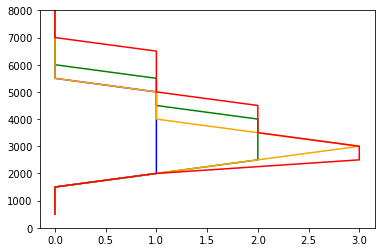

In [28]:
plt.plot(nCoreUp1_prof0_pts_d3[1,:], HAMSL_d3, ls='-', color='b')
plt.plot(nCoreUp2_prof0_pts_d3[1,:], HAMSL_d3, ls='-', color='g')
plt.plot(nCoreUp3_prof0_pts_d3[1,:], HAMSL_d3, ls='-', color='orange')
plt.plot(nCoreUp4_prof0_pts_d3[1,:], HAMSL_d3, ls='-', color='r')
plt.ylim(0,8000)

(0.0, 8000.0)

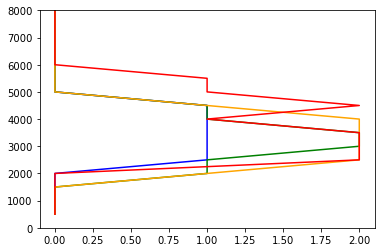

In [29]:
plt.plot(nCoreUp1_prof0_pts_d4[1,:], HAMSL_d4, ls='-', color='b')
plt.plot(nCoreUp2_prof0_pts_d4[1,:], HAMSL_d4, ls='-', color='g')
plt.plot(nCoreUp3_prof0_pts_d4[1,:], HAMSL_d4, ls='-', color='orange')
plt.plot(nCoreUp4_prof0_pts_d4[1,:], HAMSL_d4, ls='-', color='r')
plt.ylim(0,8000)

(0.0, 8000.0)

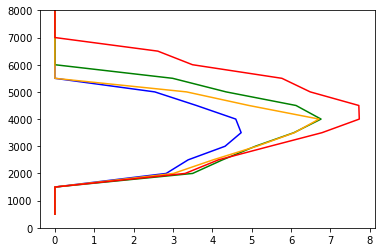

In [36]:
plt.plot(CoreMaxW1_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='b')
plt.plot(CoreMaxW2_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='g')
plt.plot(CoreMaxW3_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='orange')
plt.plot(CoreMaxW4_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='r')
plt.ylim(0,8000)

(0.0, 8000.0)

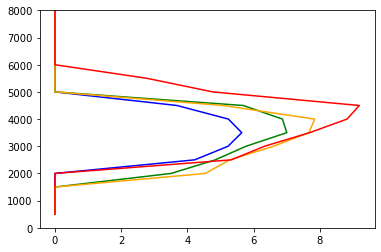

In [35]:
plt.plot(CoreMaxW1_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='b')
plt.plot(CoreMaxW2_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='g')
plt.plot(CoreMaxW3_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='orange')
plt.plot(CoreMaxW4_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='r')
plt.ylim(0,8000)

(0.0, 8000.0)

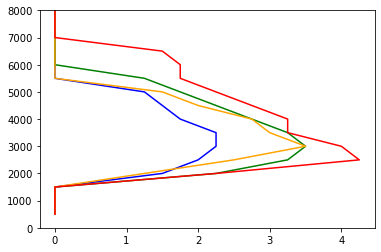

In [48]:
plt.plot(CoreAreaUp1_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='b')
plt.plot(CoreAreaUp2_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='g')
plt.plot(CoreAreaUp3_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='orange')
plt.plot(CoreAreaUp4_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='r')
plt.ylim(0,8000)

(0.0, 8000.0)

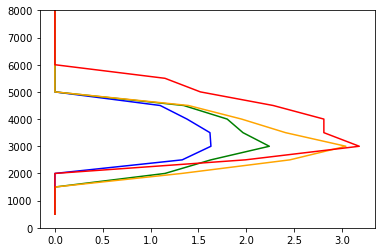

In [50]:
plt.plot(CoreAreaUp1_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='b')
plt.plot(CoreAreaUp2_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='g')
plt.plot(CoreAreaUp3_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='orange')
plt.plot(CoreAreaUp4_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='r')
plt.ylim(0,8000)

(0.0, 8000.0)

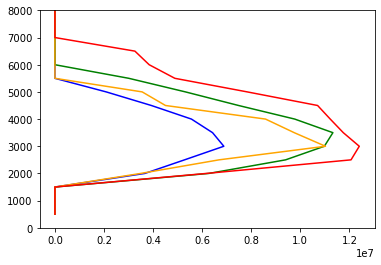

In [51]:
plt.plot(MassFluxUp1_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='b')
plt.plot(MassFluxUp2_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='g')
plt.plot(MassFluxUp3_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='orange')
plt.plot(MassFluxUp4_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='r')
plt.ylim(0,8000)

(0.0, 8000.0)

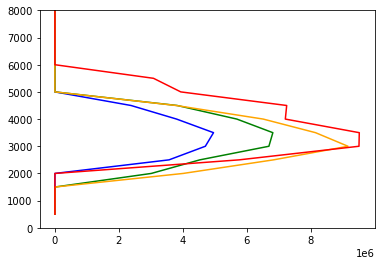

In [52]:
plt.plot(MassFluxUp1_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='b')
plt.plot(MassFluxUp2_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='g')
plt.plot(MassFluxUp3_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='orange')
plt.plot(MassFluxUp4_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='r')
plt.ylim(0,8000)

In [56]:
# plt.plot(nCoreUp1_maxprof_pts_d3[1,:], HAMSL_d3, ls='--', color='b')
# plt.plot(nCoreUp2_maxprof_pts_d3[1,:], HAMSL_d3, ls='--', color='g')
# plt.plot(nCoreUp3_maxprof_pts_d3[1,:], HAMSL_d3, ls='--', color='orange')
# plt.plot(nCoreUp4_maxprof_pts_d3[1,:], HAMSL_d3, ls='--', color='r')
# plt.plot(nCoreUp1_maxprof_pts_d4[1,:], HAMSL_d4, ls='-', color='b')
# plt.plot(nCoreUp2_maxprof_pts_d4[1,:], HAMSL_d4, ls='-', color='g')
# plt.plot(nCoreUp3_maxprof_pts_d4[1,:], HAMSL_d4, ls='-', color='orange')
# plt.plot(nCoreUp4_maxprof_pts_d4[1,:], HAMSL_d4, ls='-', color='r')
# plt.ylim(0,15000)

In [57]:
# plt.plot(CoreMaxW1_prof0_pts_d3[1,:,0], HAMSL_d3, ls='--', color='b')
# plt.plot(CoreMaxW2_prof0_pts_d3[1,:,0], HAMSL_d3, ls='--', color='g')
# plt.plot(CoreMaxW3_prof0_pts_d3[1,:,0], HAMSL_d3, ls='--', color='orange')
# plt.plot(CoreMaxW4_prof0_pts_d3[1,:,0], HAMSL_d3, ls='--', color='r')
# plt.plot(CoreMaxW1_prof0_pts_d4[1,:,0], HAMSL_d4, color='b')
# plt.plot(CoreMaxW2_prof0_pts_d4[1,:,0], HAMSL_d4, color='g')
# plt.plot(CoreMaxW3_prof0_pts_d4[1,:,0], HAMSL_d4, color='orange')
# plt.plot(CoreMaxW4_prof0_pts_d4[1,:,0], HAMSL_d4, color='r')
# plt.ylim(0,7000)

In [58]:
# plt.plot(CoreMaxW1_maxprof_pts_d3[1,:,0], HAMSL_d3, ls='--', color='b')
# plt.plot(CoreMaxW2_maxprof_pts_d3[1,:,0], HAMSL_d3, ls='--', color='g')
# plt.plot(CoreMaxW3_maxprof_pts_d3[1,:,0], HAMSL_d3, ls='--', color='orange')
# plt.plot(CoreMaxW4_maxprof_pts_d3[1,:,0], HAMSL_d3, ls='--', color='r')
# plt.plot(CoreMaxW1_maxprof_pts_d4[1,:,0], HAMSL_d4, ls='-', color='b')
# plt.plot(CoreMaxW2_maxprof_pts_d4[1,:,0], HAMSL_d4, ls='-', color='g')
# plt.plot(CoreMaxW3_maxprof_pts_d4[1,:,0], HAMSL_d4, ls='-', color='orange')
# plt.plot(CoreMaxW4_maxprof_pts_d4[1,:,0], HAMSL_d4, ls='-', color='r')
# plt.ylim(0,15000)

In [84]:
def plot_profiles_NxM(data1_avg, data2_avg, data3_avg, data1_pts, data2_pts, data3_pts, height, xlims, ylims, xlabels, titles1, titles2, legends, figname, 
                      figsize=(10, 10), nrow=1, ncol=1):
    mpl.rcParams['font.size'] = 12
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['figure.facecolor'] = 'white'
    # nrow = len(data1_avg)
    # ncol = len(data1_avg[0])
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=300)

    # ylims = [1, 15]
    colors = {'low':'blue', 'medium':'green', 'high':'crimson'}
    
    for row in range(nrow):
        for col in range(ncol):
            if nrow == 1:
                ax = axes[col]
            else:
                ax = axes[row, col]
            ax.plot(data1_avg[row][col], height, color=colors['low'], lw=5, label=legends[0])
            ax.plot(data2_avg[row][col], height, color=colors['medium'], lw=5, label=legends[1])
            ax.plot(data3_avg[row][col], height, color=colors['high'], lw=5, label=legends[2])
            # Replace left fill values with -99 if right fill value is not inf
            fill1 = [data1_pts[row][col][0], data1_pts[row][col][1]]
            fill2 = [data2_pts[row][col][0], data2_pts[row][col][1]]
            fill3 = [data3_pts[row][col][0], data3_pts[row][col][1]]
            idx1 = np.where((np.isinf(fill1[0]) & ~np.isinf(fill1[1])))
            idx2 = np.where((np.isinf(fill2[0]) & ~np.isinf(fill2[1])))
            idx3 = np.where((np.isinf(fill3[0]) & ~np.isinf(fill3[1])))
            fill1[0][idx1] = -99
            fill2[0][idx2] = -99
            fill3[0][idx3] = -99
            ax.fill_betweenx(height, fill1[0], fill1[1], color=colors['low'], edgecolor=None, alpha=0.25)
            ax.fill_betweenx(height, fill2[0], fill2[1], color=colors['medium'], edgecolor=None, alpha=0.25)
            ax.fill_betweenx(height, fill3[0], fill3[1], color=colors['high'], edgecolor=None, alpha=0.25)
#             ax.fill_betweenx(height, data1_pts[row][col][0], data1_pts[row][col][1], color=colors['low'], edgecolor=None, alpha=0.25)
#             ax.fill_betweenx(height, data2_pts[row][col][0], data2_pts[row][col][1], color=colors['medium'], edgecolor=None, alpha=0.25)
#             ax.fill_betweenx(height, data3_pts[row][col][0], data3_pts[row][col][1], color=colors['high'], edgecolor=None, alpha=0.25)
            ax.grid(ls='--')
            ax.set_xlim(xlims[row][col][0], xlims[row][col][1])
            ax.set_ylim(ylims[0], ylims[1])
            ax.set_xlabel(xlabels[row][col])
            ax.set_ylabel('Height ASL (km)')
            ax.set_title(titles1[row][col], loc='left')
            ax.set_title(titles2, loc='right', fontsize=14)
            if (row == 0) & (col == 0):
                ax.legend(loc='upper right', fontsize=12)
    
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

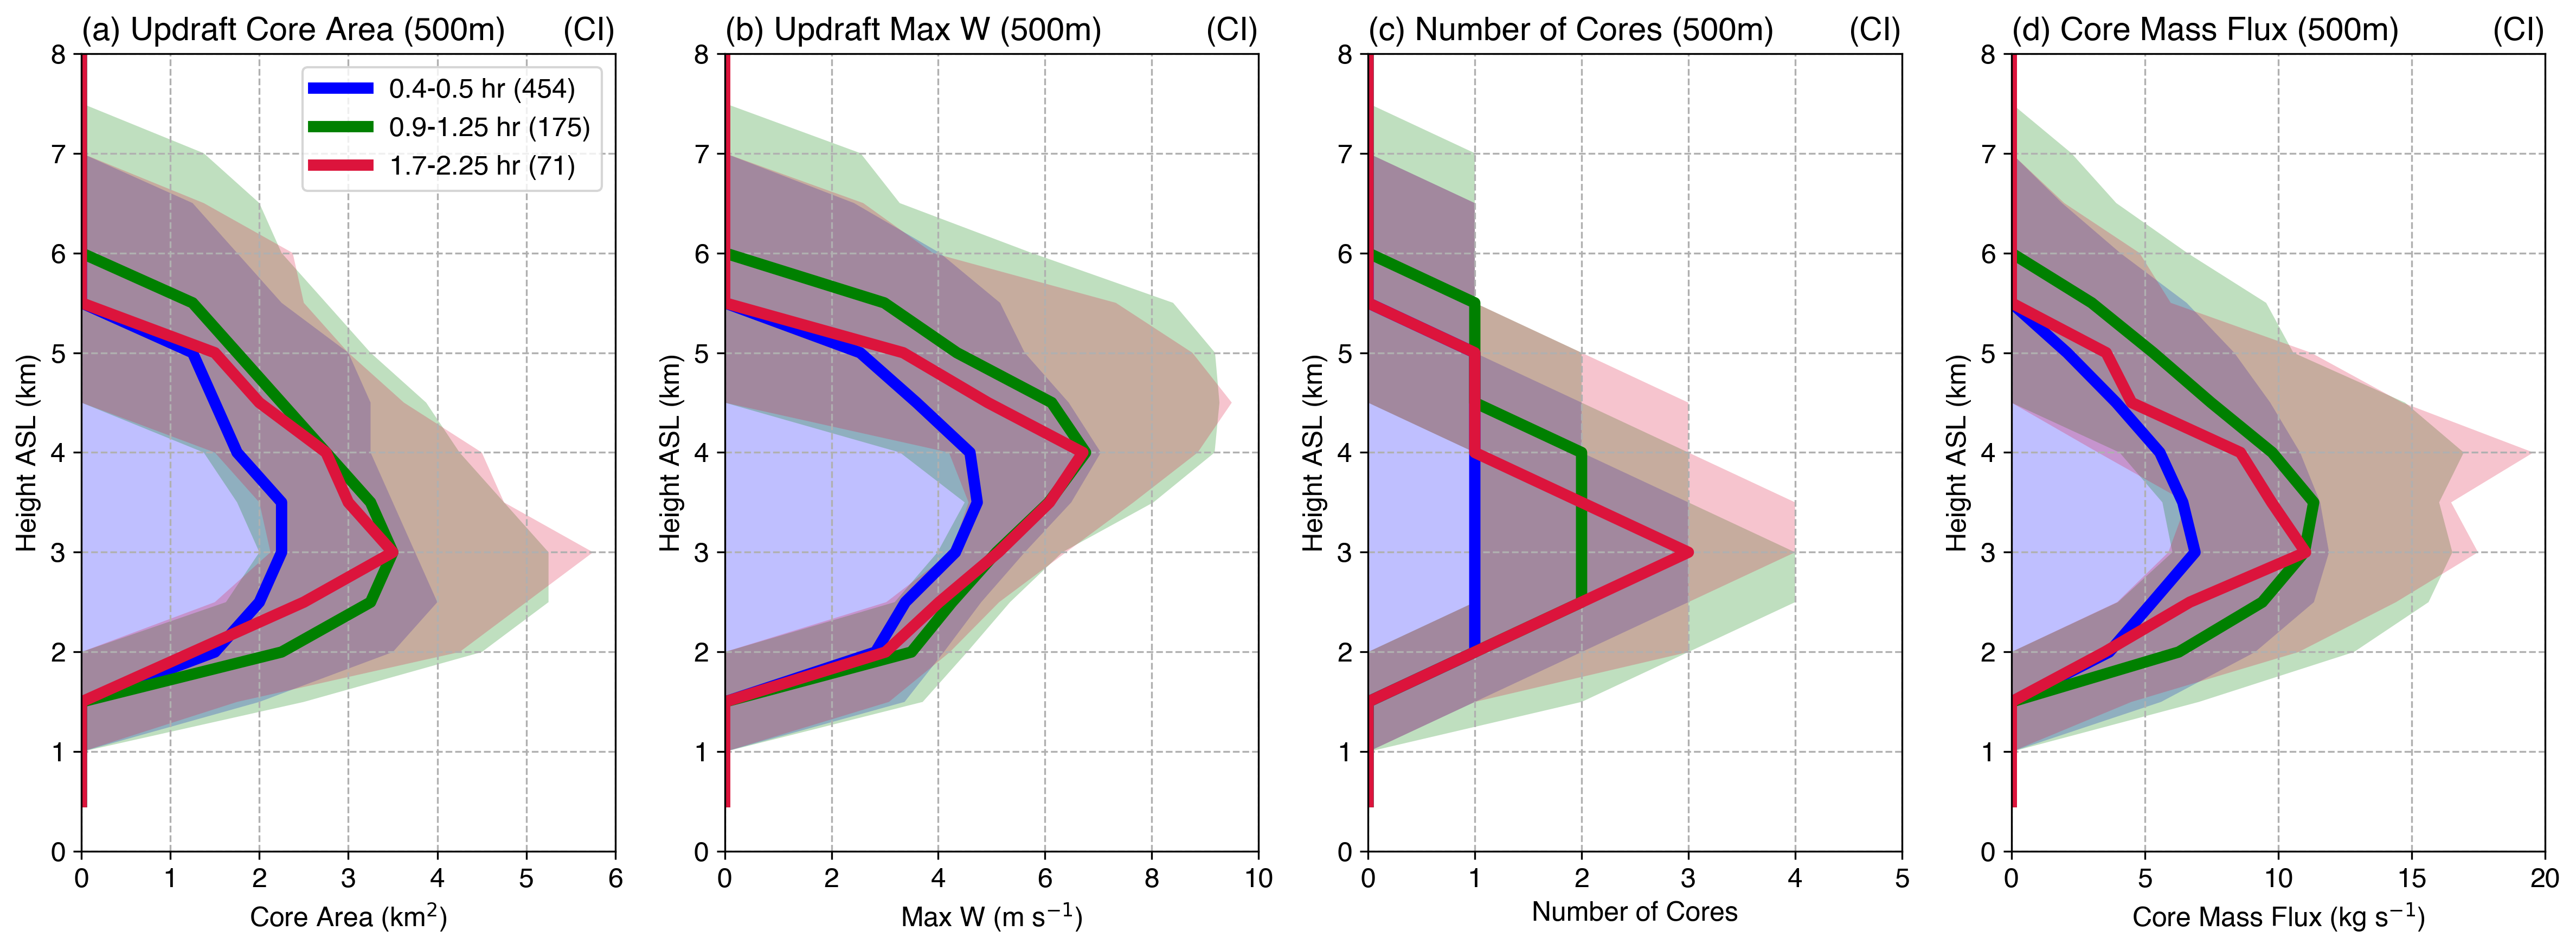

In [93]:
MFpower = 6
MFscale = 10**MFpower

data1_avg = [
    [CoreAreaUp1_prof0_pts_d3.sel(quantile=0.5).isel(core=0), 
     CoreMaxW1_prof0_pts_d3.sel(quantile=0.5).isel(core=0), 
     nCoreUp1_prof0_pts_d3.sel(quantile=0.5), 
     MassFluxUp1_prof0_pts_d3.sel(quantile=0.5).isel(core=0)/MFscale],
    [],
]
data2_avg = [
    [CoreAreaUp2_prof0_pts_d3.sel(quantile=0.5).isel(core=0), 
     CoreMaxW2_prof0_pts_d3.sel(quantile=0.5).isel(core=0), 
     nCoreUp2_prof0_pts_d3.sel(quantile=0.5), 
     MassFluxUp2_prof0_pts_d3.sel(quantile=0.5).isel(core=0)/MFscale],
    [],
]
data3_avg = [
    [CoreAreaUp3_prof0_pts_d3.sel(quantile=0.5).isel(core=0), 
     CoreMaxW3_prof0_pts_d3.sel(quantile=0.5).isel(core=0), 
     nCoreUp3_prof0_pts_d3.sel(quantile=0.5), 
     MassFluxUp3_prof0_pts_d3.sel(quantile=0.5).isel(core=0)/MFscale],
    [],
]
data1_pts = [
    [(CoreAreaUp1_prof0_pts_d3.sel(quantile=0.25).isel(core=0), CoreAreaUp1_prof0_pts_d3.sel(quantile=0.75).isel(core=0)),
     (CoreMaxW1_prof0_pts_d3.sel(quantile=0.25).isel(core=0), CoreMaxW1_prof0_pts_d3.sel(quantile=0.75).isel(core=0)),
     (nCoreUp1_prof0_pts_d3.sel(quantile=0.25), nCoreUp1_prof0_pts_d3.sel(quantile=0.75)),
     (MassFluxUp1_prof0_pts_d3.sel(quantile=0.25).isel(core=0)/MFscale, MassFluxUp1_prof0_pts_d3.sel(quantile=0.75).isel(core=0)/MFscale)],
    [],
]
data2_pts = [
    [(CoreAreaUp2_prof0_pts_d3.sel(quantile=0.25).isel(core=0), CoreAreaUp2_prof0_pts_d3.sel(quantile=0.75).isel(core=0)),
     (CoreMaxW2_prof0_pts_d3.sel(quantile=0.25).isel(core=0), CoreMaxW2_prof0_pts_d3.sel(quantile=0.75).isel(core=0)),
     (nCoreUp2_prof0_pts_d3.sel(quantile=0.25), nCoreUp2_prof0_pts_d3.sel(quantile=0.75)),
     (MassFluxUp2_prof0_pts_d3.sel(quantile=0.25).isel(core=0)/MFscale, MassFluxUp2_prof0_pts_d3.sel(quantile=0.75).isel(core=0)/MFscale)],
    [],
]
data3_pts = [
    [(CoreAreaUp3_prof0_pts_d3.sel(quantile=0.25).isel(core=0), CoreAreaUp3_prof0_pts_d3.sel(quantile=0.75).isel(core=0)),
     (CoreMaxW3_prof0_pts_d3.sel(quantile=0.25).isel(core=0), CoreMaxW3_prof0_pts_d3.sel(quantile=0.75).isel(core=0)),
     (nCoreUp3_prof0_pts_d3.sel(quantile=0.25), nCoreUp3_prof0_pts_d3.sel(quantile=0.75)),
     (MassFluxUp3_prof0_pts_d3.sel(quantile=0.25).isel(core=0)/MFscale, MassFluxUp3_prof0_pts_d3.sel(quantile=0.75).isel(core=0)/MFscale)],
    [],
]
xlims = [[(0,6), (0,10), (0,5), (0, 20)]]
ylims = (0, 8)
xlabels = [['Core Area (km$^2$)', 'Max W (m s$^{-1}$)', 'Number of Cores', 'Core Mass Flux (kg s$^{-1}$)']]
figname = f'{figdir}cell_initiation_w_profiles_d3.png'
titles1 = [['(a) Updraft Core Area (500m)', '(b) Updraft Max W (500m)', '(c) Number of Cores (500m)', '(d) Core Mass Flux (500m)']]
titles2 = '(CI)'
legends = [f'{lifetime_range1[0]}-{lifetime_range1[1]} hr ({ntracks1_Up_d3})',
           f'{lifetime_range2[0]}-{lifetime_range2[1]} hr ({ntracks2_Up_d3})',
           f'{lifetime_range3[0]}-{lifetime_range3[1]} hr ({ntracks3_Up_d3})',]
figsize = (16, 6)
fig = plot_profiles_NxM(data1_avg, data2_avg, data3_avg, data1_pts, data2_pts, data3_pts, HAMSL_d3/1000, xlims, ylims, xlabels, titles1, titles2, legends, figname, 
                        figsize=figsize, nrow=1, ncol=4)

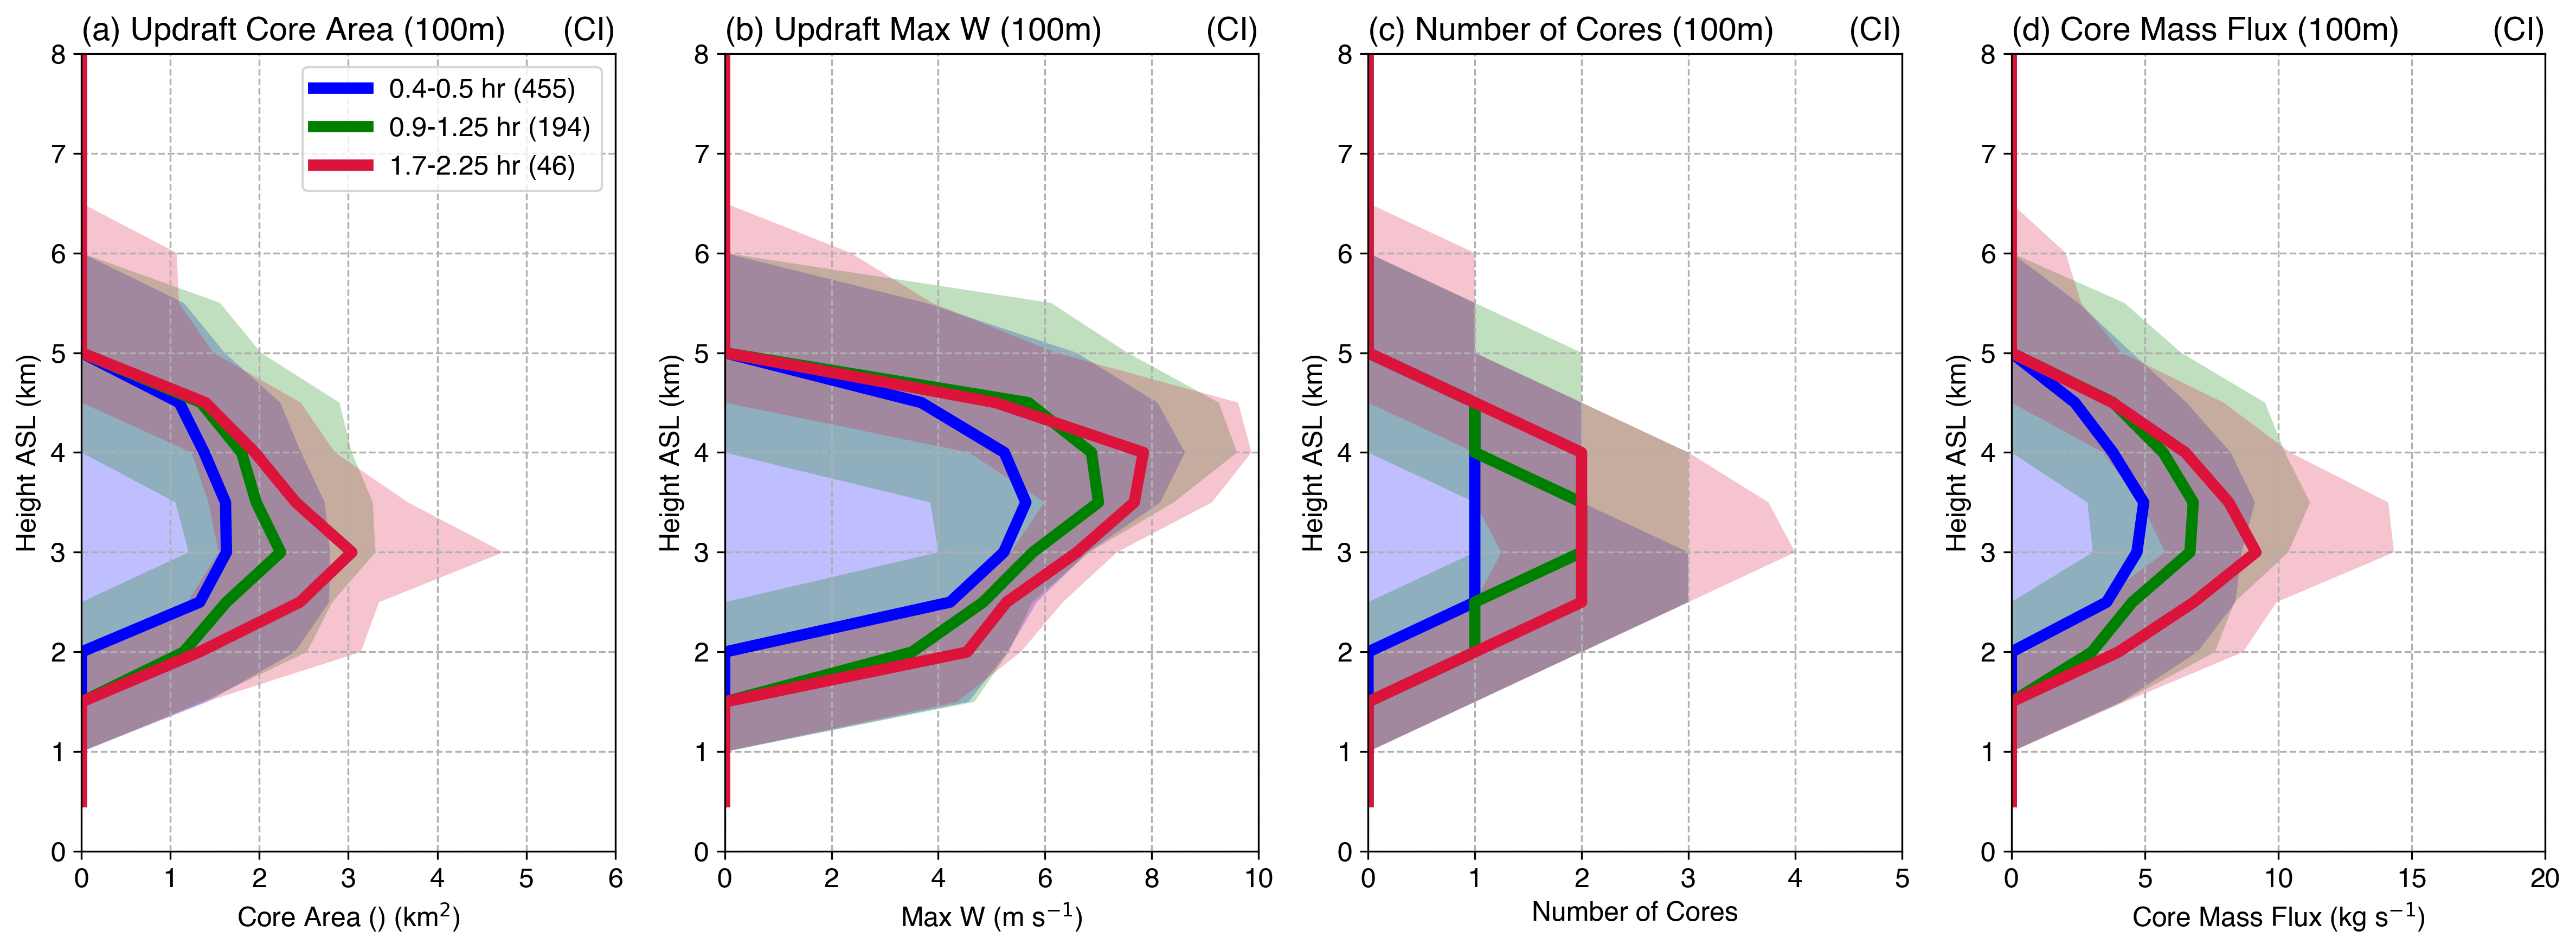

In [92]:
data1_avg = [
    [CoreAreaUp1_prof0_pts_d4.sel(quantile=0.5).isel(core=0), 
     CoreMaxW1_prof0_pts_d4.sel(quantile=0.5).isel(core=0), 
     nCoreUp1_prof0_pts_d4.sel(quantile=0.5), 
     MassFluxUp1_prof0_pts_d4.sel(quantile=0.5).isel(core=0)/MFscale],
    [],
]
data2_avg = [
    [CoreAreaUp2_prof0_pts_d4.sel(quantile=0.5).isel(core=0), 
     CoreMaxW2_prof0_pts_d4.sel(quantile=0.5).isel(core=0), 
     nCoreUp2_prof0_pts_d4.sel(quantile=0.5), 
     MassFluxUp2_prof0_pts_d4.sel(quantile=0.5).isel(core=0)/MFscale],
    [],
]
data3_avg = [
    [CoreAreaUp3_prof0_pts_d4.sel(quantile=0.5).isel(core=0), 
     CoreMaxW3_prof0_pts_d4.sel(quantile=0.5).isel(core=0), 
     nCoreUp3_prof0_pts_d4.sel(quantile=0.5), 
     MassFluxUp3_prof0_pts_d4.sel(quantile=0.5).isel(core=0)/MFscale],
    [],
]
data1_pts = [
    [(CoreAreaUp1_prof0_pts_d4.sel(quantile=0.25).isel(core=0), CoreAreaUp1_prof0_pts_d4.sel(quantile=0.75).isel(core=0)),
     (CoreMaxW1_prof0_pts_d4.sel(quantile=0.25).isel(core=0), CoreMaxW1_prof0_pts_d4.sel(quantile=0.75).isel(core=0)),
     (nCoreUp1_prof0_pts_d4.sel(quantile=0.25), nCoreUp1_prof0_pts_d4.sel(quantile=0.75)),
     (MassFluxUp1_prof0_pts_d4.sel(quantile=0.25).isel(core=0)/MFscale, MassFluxUp1_prof0_pts_d4.sel(quantile=0.75).isel(core=0)/MFscale)],
    [],
]
data2_pts = [
    [(CoreAreaUp2_prof0_pts_d4.sel(quantile=0.25).isel(core=0), CoreAreaUp2_prof0_pts_d4.sel(quantile=0.75).isel(core=0)),
     (CoreMaxW2_prof0_pts_d4.sel(quantile=0.25).isel(core=0), CoreMaxW2_prof0_pts_d4.sel(quantile=0.75).isel(core=0)),
     (nCoreUp2_prof0_pts_d4.sel(quantile=0.25), nCoreUp2_prof0_pts_d4.sel(quantile=0.75)),
     (MassFluxUp2_prof0_pts_d4.sel(quantile=0.25).isel(core=0)/MFscale, MassFluxUp2_prof0_pts_d4.sel(quantile=0.75).isel(core=0)/MFscale)],
    [],
]
data3_pts = [
    [(CoreAreaUp3_prof0_pts_d4.sel(quantile=0.25).isel(core=0), CoreAreaUp3_prof0_pts_d4.sel(quantile=0.75).isel(core=0)),
     (CoreMaxW3_prof0_pts_d4.sel(quantile=0.25).isel(core=0), CoreMaxW3_prof0_pts_d4.sel(quantile=0.75).isel(core=0)),
     (nCoreUp3_prof0_pts_d4.sel(quantile=0.25), nCoreUp3_prof0_pts_d4.sel(quantile=0.75)),
     (MassFluxUp3_prof0_pts_d4.sel(quantile=0.25).isel(core=0)/MFscale, MassFluxUp3_prof0_pts_d4.sel(quantile=0.75).isel(core=0)/MFscale)],
    [],
]
xlims = [[(0,6), (0,10), (0,5), (0, 20)]]
ylims = (0, 8)
xlabels = [['Core Area () (km$^2$)', 'Max W (m s$^{-1}$)', 'Number of Cores', 'Core Mass Flux (kg s$^{-1}$)']]
figname = f'{figdir}cell_initiation_w_profiles_d4.png'
titles1 = [['(a) Updraft Core Area (100m)', '(b) Updraft Max W (100m)', '(c) Number of Cores (100m)', '(d) Core Mass Flux (100m)']]
titles2 = '(CI)'
legends = [f'{lifetime_range1[0]}-{lifetime_range1[1]} hr ({ntracks1_Up_d4})',
           f'{lifetime_range2[0]}-{lifetime_range2[1]} hr ({ntracks2_Up_d4})',
           f'{lifetime_range3[0]}-{lifetime_range3[1]} hr ({ntracks3_Up_d4})',]
figsize = (16, 6)
fig = plot_profiles_NxM(data1_avg, data2_avg, data3_avg, data1_pts, data2_pts, data3_pts, HAMSL_d4/1000, xlims, ylims, xlabels, titles1, titles2, legends, figname, 
                        figsize=figsize, nrow=1, ncol=4)

In [90]:
figdir

'/gpfs/wolf/cli120/proj-shared/zfeng/cacti/pyflextrkr_paper/'

# Composite updraft core time-series profiles by lifetime

In [94]:
def quantiles_time_by1cond(in_var, cond1_var, cond1_range, loc_var, loc_range, merge_tracknumber, split_tracknumber, quantiles, fillval=-99):
    in_var_cond = in_var.where((loc_var >= loc_range[0]) & (loc_var <= loc_range[1]) &
                                (cond1_var > cond1_range[0]) & (cond1_var <= cond1_range[1]) & 
                                (np.isnan(merge_tracknumber)) & (np.isnan(split_tracknumber)), drop=True)

    nsamples = in_var_cond.sizes['tracks']
    
    # Replace NaN with a fill value to take into account decreasing sample with height
    # NaN is excluded in quantile calculations which biases the sampling with increasing height
    in_var_cond = in_var_cond.where(~np.isnan(in_var_cond), other=fillval)
    
    # Get time-series quantile
    out_var_cond_pts = in_var_cond.quantile(quantiles, dim='tracks', skipna=True)
    
    return (nsamples, out_var_cond_pts)

In [95]:
# Get initiation and lifetime-max profile
lifetime_range1 = [0.4,0.5]
lifetime_range2 = [0.9,1.25]
lifetime_range3 = [1.7,2.25]
lifetime_range4 = [2.25,3.5]

lon_SDC = -65
lon_eSDC = [-65, -63]

quantiles_timeseries = [0.5,0.9]
ntracks1_Up_d3, nCoreUp1_d3 = quantiles_time_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks2_Up_d3, nCoreUp2_d3 = quantiles_time_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks3_Up_d3, nCoreUp3_d3 = quantiles_time_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks4_Up_d3, nCoreUp4_d3 = quantiles_time_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)

In [96]:
ntracks1_Up_d4, nCoreUp1_d4 = quantiles_time_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks2_Up_d4, nCoreUp2_d4 = quantiles_time_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks3_Up_d4, nCoreUp3_d4 = quantiles_time_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks4_Up_d4, nCoreUp4_d4 = quantiles_time_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)

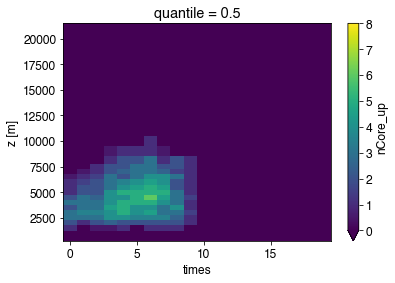

In [97]:
nCoreUp4_d3.sel(quantile=0.5).isel(times=slice(0,20)).transpose().plot(vmin=0, vmax=8)

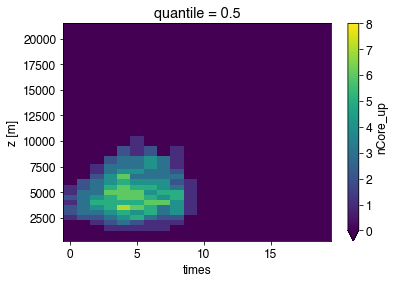

In [98]:
nCoreUp4_d4.sel(quantile=0.5).isel(times=slice(0,20)).transpose().plot(vmin=0, vmax=8)

In [99]:
ntracks1_Up_d3, CoreMaxWUp1_d3 = quantiles_time_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks2_Up_d3, CoreMaxWUp2_d3 = quantiles_time_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks3_Up_d3, CoreMaxWUp3_d3 = quantiles_time_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks4_Up_d3, CoreMaxWUp4_d3 = quantiles_time_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)

In [100]:
ntracks1_Up_d4, CoreMaxWUp1_d4 = quantiles_time_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks2_Up_d4, CoreMaxWUp2_d4 = quantiles_time_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks3_Up_d4, CoreMaxWUp3_d4 = quantiles_time_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks4_Up_d4, CoreMaxWUp4_d4 = quantiles_time_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)

In [101]:
ntracks1_Up_d3, CoreAreaUp1_d3 = quantiles_time_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks2_Up_d3, CoreAreaUp2_d3 = quantiles_time_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks3_Up_d3, CoreAreaUp3_d3 = quantiles_time_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks4_Up_d3, CoreAreaUp4_d3 = quantiles_time_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)

In [102]:
ntracks1_Up_d4, CoreAreaUp1_d4 = quantiles_time_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks2_Up_d4, CoreAreaUp2_d4 = quantiles_time_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks3_Up_d4, CoreAreaUp3_d4 = quantiles_time_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks4_Up_d4, CoreAreaUp4_d4 = quantiles_time_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)

In [103]:
ntracks1_Up_d3, MassFluxUp1_d3 = quantiles_time_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks2_Up_d3, MassFluxUp2_d3 = quantiles_time_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks3_Up_d3, MassFluxUp3_d3 = quantiles_time_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks4_Up_d3, MassFluxUp4_d3 = quantiles_time_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)

In [104]:
ntracks1_Up_d4, MassFluxUp1_d4 = quantiles_time_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks2_Up_d4, MassFluxUp2_d4 = quantiles_time_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks3_Up_d4, MassFluxUp3_d4 = quantiles_time_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks4_Up_d4, MassFluxUp4_d4 = quantiles_time_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)

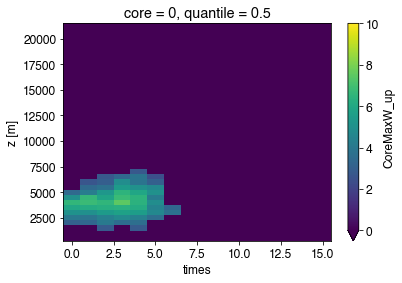

In [105]:
# lev = np.arange(0, 18.1, 1)
CoreMaxWUp3_d3.sel(quantile=0.5).isel(times=slice(0,16), core=0).transpose().plot(vmin=0, vmax=10)

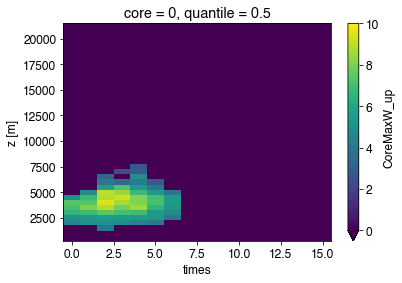

In [106]:
# lev = np.arange(0, 18.1, 1)
CoreMaxWUp3_d4.sel(quantile=0.5).isel(times=slice(0,16), core=0).transpose().plot(vmin=0, vmax=10)

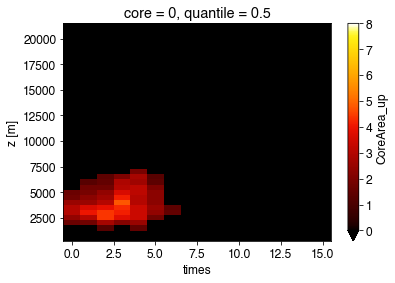

In [107]:
CoreAreaUp3_d3.sel(quantile=0.5).isel(times=slice(0,16), core=0).transpose().plot(vmin=0, vmax=8, cmap=cc.cm['fire'])

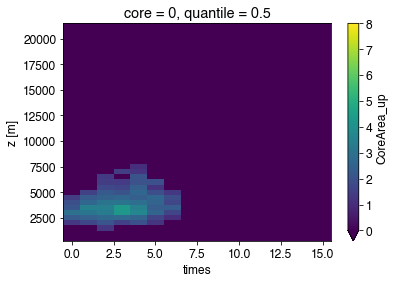

In [108]:
CoreAreaUp3_d4.sel(quantile=0.5).isel(times=slice(0,16), core=0).transpose().plot(vmin=0, vmax=8)

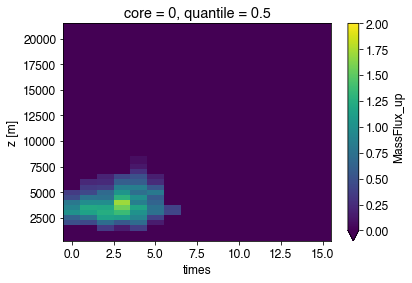

In [109]:
MFscale = 1e7
(MassFluxUp3_d3/MFscale).sel(quantile=0.5).isel(times=slice(0,16), core=0).transpose().plot(vmin=0, vmax=2)

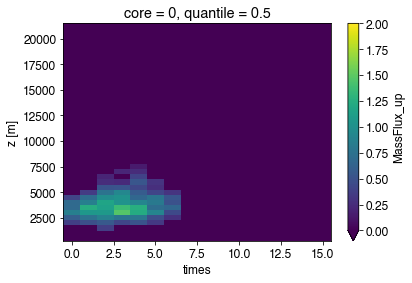

In [110]:
(MassFluxUp3_d4/MFscale).sel(quantile=0.5).isel(times=slice(0,16), core=0).transpose().plot(vmin=0, vmax=2)

# Composite downdraft core statistics by lifetime

In [111]:
ntracks1_Dn_d3, nCoreDn1_d3 = quantiles_time_by1cond(ds_d3.nCore_down, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks2_Dn_d3, nCoreDn2_d3 = quantiles_time_by1cond(ds_d3.nCore_down, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks3_Dn_d3, nCoreDn3_d3 = quantiles_time_by1cond(ds_d3.nCore_down, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks4_Dn_d3, nCoreDn4_d3 = quantiles_time_by1cond(ds_d3.nCore_down, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)

In [112]:
ntracks1_Dn_d4, nCoreDn1_d4 = quantiles_time_by1cond(ds_d4.nCore_down, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks2_Dn_d4, nCoreDn2_d4 = quantiles_time_by1cond(ds_d4.nCore_down, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks3_Dn_d4, nCoreDn3_d4 = quantiles_time_by1cond(ds_d4.nCore_down, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks4_Dn_d4, nCoreDn4_d4 = quantiles_time_by1cond(ds_d4.nCore_down, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)

In [113]:
ntracks1_Dn_d3, CoreAreaDn1_d3 = quantiles_time_by1cond(ds_d3.CoreArea_down, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks2_Dn_d3, CoreAreaDn2_d3 = quantiles_time_by1cond(ds_d3.CoreArea_down, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks3_Dn_d3, CoreAreaDn3_d3 = quantiles_time_by1cond(ds_d3.CoreArea_down, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks4_Dn_d3, CoreAreaDn4_d3 = quantiles_time_by1cond(ds_d3.CoreArea_down, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)

In [114]:
ntracks1_Dn_d4, CoreAreaDn1_d4 = quantiles_time_by1cond(ds_d4.CoreArea_down, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks2_Dn_d4, CoreAreaDn2_d4 = quantiles_time_by1cond(ds_d4.CoreArea_down, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks3_Dn_d4, CoreAreaDn3_d4 = quantiles_time_by1cond(ds_d4.CoreArea_down, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks4_Dn_d4, CoreAreaDn4_d4 = quantiles_time_by1cond(ds_d4.CoreArea_down, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)

In [115]:
ntracks1_Dn_d3, CoreMinWDn1_d3 = quantiles_time_by1cond(ds_d3.CoreMinW_down, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)
ntracks2_Dn_d3, CoreMinWDn2_d3 = quantiles_time_by1cond(ds_d3.CoreMinW_down, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)
ntracks3_Dn_d3, CoreMinWDn3_d3 = quantiles_time_by1cond(ds_d3.CoreMinW_down, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)
ntracks4_Dn_d3, CoreMinWDn4_d3 = quantiles_time_by1cond(ds_d3.CoreMinW_down, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)

In [116]:
ntracks1_Dn_d4, CoreMinWDn1_d4 = quantiles_time_by1cond(ds_d4.CoreMinW_down, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)
ntracks2_Dn_d4, CoreMinWDn2_d4 = quantiles_time_by1cond(ds_d4.CoreMinW_down, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)
ntracks3_Dn_d4, CoreMinWDn3_d4 = quantiles_time_by1cond(ds_d4.CoreMinW_down, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)
ntracks4_Dn_d4, CoreMinWDn4_d4 = quantiles_time_by1cond(ds_d4.CoreMinW_down, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)

In [117]:
ntracks1_Dn_d3, MassFluxDn1_d3 = quantiles_time_by1cond(ds_d3.MassFlux_down, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)
ntracks2_Dn_d3, MassFluxDn2_d3 = quantiles_time_by1cond(ds_d3.MassFlux_down, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)
ntracks3_Dn_d3, MassFluxDn3_d3 = quantiles_time_by1cond(ds_d3.MassFlux_down, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)
ntracks4_Dn_d3, MassFluxDn4_d3 = quantiles_time_by1cond(ds_d3.MassFlux_down, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)

In [118]:
ntracks1_Dn_d4, MassFluxDn1_d4 = quantiles_time_by1cond(ds_d4.MassFlux_down, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)
ntracks2_Dn_d4, MassFluxDn2_d4 = quantiles_time_by1cond(ds_d4.MassFlux_down, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)
ntracks3_Dn_d4, MassFluxDn3_d4 = quantiles_time_by1cond(ds_d4.MassFlux_down, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)
ntracks4_Dn_d4, MassFluxDn4_d4 = quantiles_time_by1cond(ds_d4.MassFlux_down, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)

In [119]:
nCoreUp2_d3.where(nCoreUp2_d3 >= 0, other=np.NaN)

<xarray.DataArray 'nCore_up' (quantile: 2, times: 60, z: 29)>
array([[[0. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. ],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[0. , 1. , 4. , ..., 0. , 0. , 0. ],
        [0. , 1. , 5. , ..., 0. , 0. , 0. ],
        [0. , 2. , 3.7, ..., 0. , 0. , 0. ],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * times     (times) int64 0 1 2 3 4 5 6 7 8 9 ... 51 52 53 54 55 56 57 58 59
  * z         (z) float64 500.0 1e+03 1.5e+03 2e+03 ... 1.9e+04 2e+04 2.1e+04
  * quantile  (quantile) float64 0.5 0.9

In [147]:
def plot_timeheight_Nvars(times, heights, dataarr, levels, cmaps, xlims, ylims, xlabels, xticks, yticks, titles, cblabels, cbticks, legend1, legend2, figname, 
                          oob_colors=None, figsize=[12,15]):

    mpl.rcParams['font.size'] = 12
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['figure.facecolor'] = 'white'

    fig = plt.figure(figsize=figsize, dpi=100)
    nrows = len(dataarr)
    gs = gridspec.GridSpec(nrows,4, height_ratios=np.repeat(1, nrows).tolist(), width_ratios=[1,1,1,0.04])
    gs.update(left=0.05, right=0.9, bottom=0.05, top=0.95, wspace=0.18, hspace=0.15)
    ylabels = ['Height ASL (km)','','']

    pcm_save = []
    for row in range(nrows):
        cmap = copy.copy(plt.get_cmap(cmaps[row]))
        norm = mpl.colors.BoundaryNorm(boundaries=levels[row], ncolors=cmap.N)
        for col in range(3):
            ax1 = plt.subplot(gs[row,col])
            Zm = np.ma.masked_invalid(dataarr[row][col])
            # if mask_method == '<':
            #     Zm = np.ma.masked_where(Zm <= 0, Zm)
            #     # Zm = np.ma.masked_where(Zm <= min(levels[row]), Zm)
            # if mask_method == '>':
            #     Zm = np.ma.masked_where(Zm >= max(levels[row]), Zm)
            pcm = ax1.pcolormesh(times, heights, Zm, shading='auto', norm=norm, cmap=cmap)
            if (row == nrows-1):
                ax1.set_xlabel(xlabels)
                ax1.annotate("", xy=(1, -0.25), xycoords='axes fraction', xytext=(0, -0.24), arrowprops=dict(facecolor='black'))
            ax1.set_ylabel(ylabels[col])
            if (row == 0):
                ax1.set_title(titles[col], loc='left', fontsize=16)
            if (row <= 1):
                ax1.text(.98, .9, legend2[row][col], ha='right', transform=ax1.transAxes)
            if (col == 0):
                ax1.text(0.02, 0.9, legend1[row], ha='left', fontsize=14, transform=ax1.transAxes)
            ax1.set_xlim(np.min(xlims), np.max(xlims))
            ax1.set_ylim(np.min(ylims), np.max(ylims))
            ax1.set_xticks(xticks)
            ax1.set_yticks(yticks)
            ax1.grid(ls='--')
            if oob_colors is not None:
                pcm.cmap.set_over(oob_colors[row]['over'])
                pcm.cmap.set_under(oob_colors[row]['under'])
                pcm.set_clim(min(levels[row]), max(levels[row]))
            # ax1.fill_between([np.min(xlims), np.max(xlims)], radar_alt, 0, color='darkgray')
        # Save pcolormesh object for plotting colorbar
        pcm_save.append(pcm)

        # Colorbar
        cax = plt.subplot(gs[row,3])
        cbar = plt.colorbar(pcm, cax=cax, label=cblabels[row], extend='both', ticks=cbticks[row])

    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

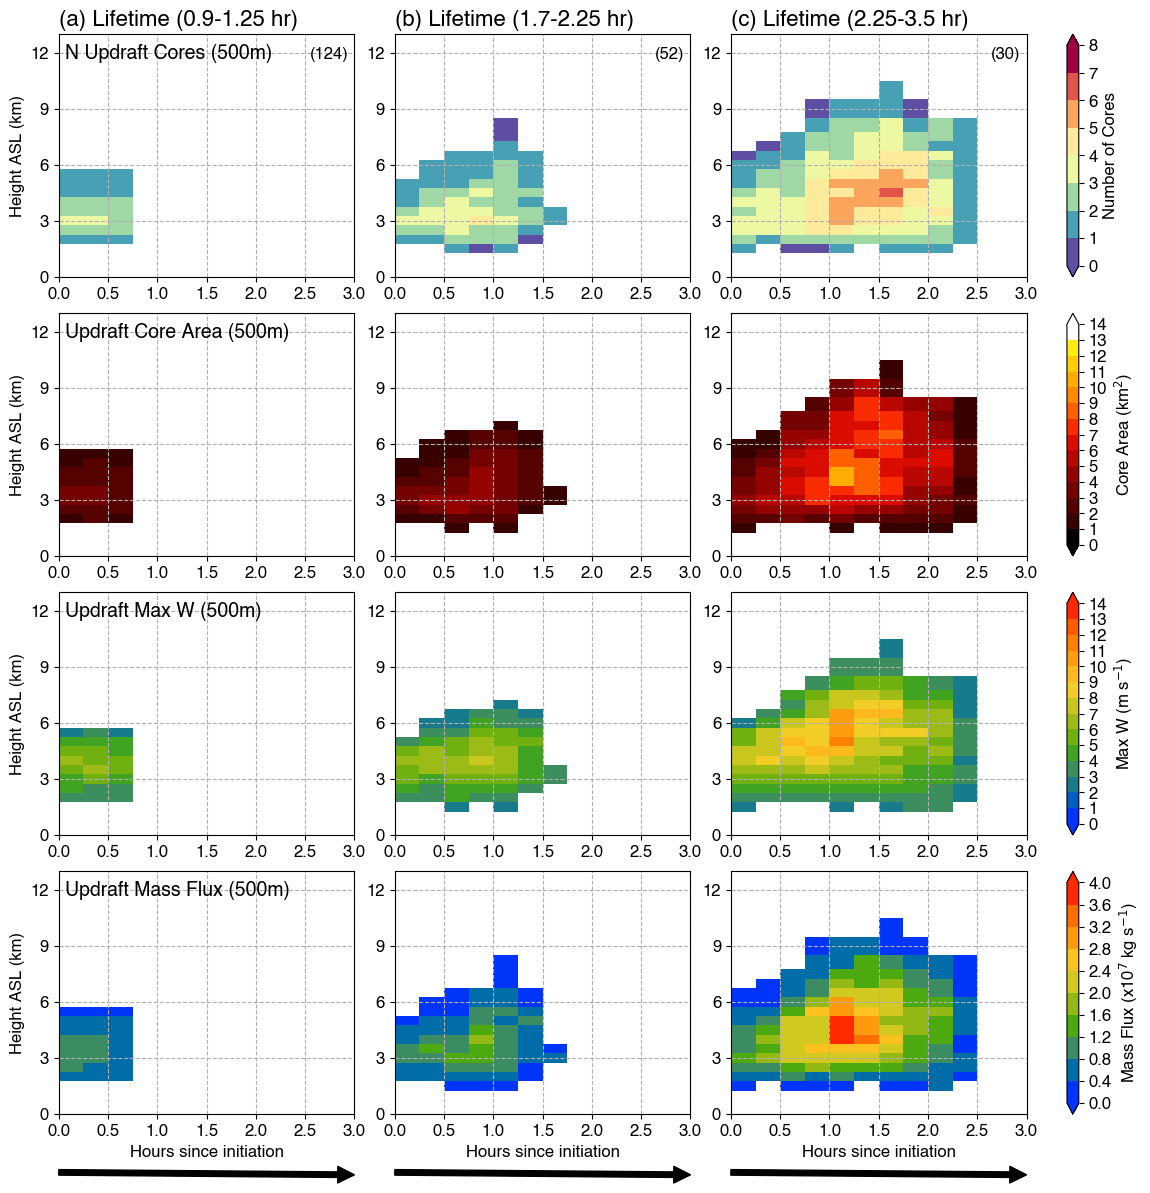

In [148]:
times_hour = ds_d3.times * time_res_d3 + time_res_d3/2
legend1 = [f'N Updraft Cores ({gridspacing_d3})', f'Updraft Core Area ({gridspacing_d3})', f'Updraft Max W ({gridspacing_d3})', f'Updraft Mass Flux ({gridspacing_d3})']
legend2 = [
    [f'({ntracks2_Up_d3})', f'({ntracks3_Up_d3})', f'({ntracks4_Up_d3})'],
    ['', '', ''],
]
qntl = 0.5
MFpower = 7
MFscale = 10**MFpower
dataarr = [
    [nCoreUp2_d3.where(nCoreUp2_d3 > 0).sel(quantile=qntl).transpose(),
     nCoreUp3_d3.where(nCoreUp3_d3 > 0).sel(quantile=qntl).transpose(),
     nCoreUp4_d3.where(nCoreUp4_d3 > 0).sel(quantile=qntl).transpose(),],
    [CoreAreaUp2_d3.where(CoreAreaUp2_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp3_d3.where(CoreAreaUp3_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp4_d3.where(CoreAreaUp4_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMaxWUp2_d3.where(CoreMaxWUp2_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp3_d3.where(CoreMaxWUp3_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp4_d3.where(CoreMaxWUp4_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [MassFluxUp2_d3.where(MassFluxUp2_d3 > 0).sel(quantile=qntl).isel(core=0).transpose()/MFscale,
     MassFluxUp3_d3.where(MassFluxUp3_d3 > 0).sel(quantile=qntl).isel(core=0).transpose()/MFscale,
     MassFluxUp4_d3.where(MassFluxUp4_d3 > 0).sel(quantile=qntl).isel(core=0).transpose()/MFscale,],
]
lev_nCore = np.arange(0, 8.1, 1)
lev_CoreArea = np.arange(0, 14.1, 1)
lev_CoreMaxW = np.arange(0, 14.1, 1)
lev_MassFlux = np.arange(0, 4.01, 0.4)
levels = [lev_nCore, lev_CoreArea, lev_CoreMaxW, lev_MassFlux]
cbticks = levels
cmaps = ['Spectral_r', cc.cm['fire'], cc.cm['rainbow'], cc.cm['rainbow']]
cblabel = ['Number of Cores', 'Core Area (km$^2$)', 'Max W (m s$^{-1}$)', f'Mass Flux (x10$^{MFpower}$ '+'kg s$^{-1}$)']
xlims = (0, 3.0)
ylims = (0, 13)
xticks = np.arange(0, 3.01, 0.5)
yticks = np.arange(0, 12.1, 3)
xlabels = 'Hours since initiation'
titles = [f'(a) Lifetime ({lifetime_range2[0]}-{lifetime_range2[1]} hr)', 
          f'(b) Lifetime ({lifetime_range3[0]}-{lifetime_range3[1]} hr)', 
          f'(c) Lifetime ({lifetime_range4[0]}-{lifetime_range4[1]} hr)']
figname = f'{figdir}celltrack_composite_updraft_profile_evolution_{qntl*100:.0f}quantile_d3.png'
fig = plot_timeheight_Nvars(times_hour, HAMSL_d3/1000, dataarr, levels, cmaps, xlims, ylims, xlabels, xticks, yticks, titles, cblabel, cbticks, legend1, legend2, figname, 
                            figsize=[12,12])

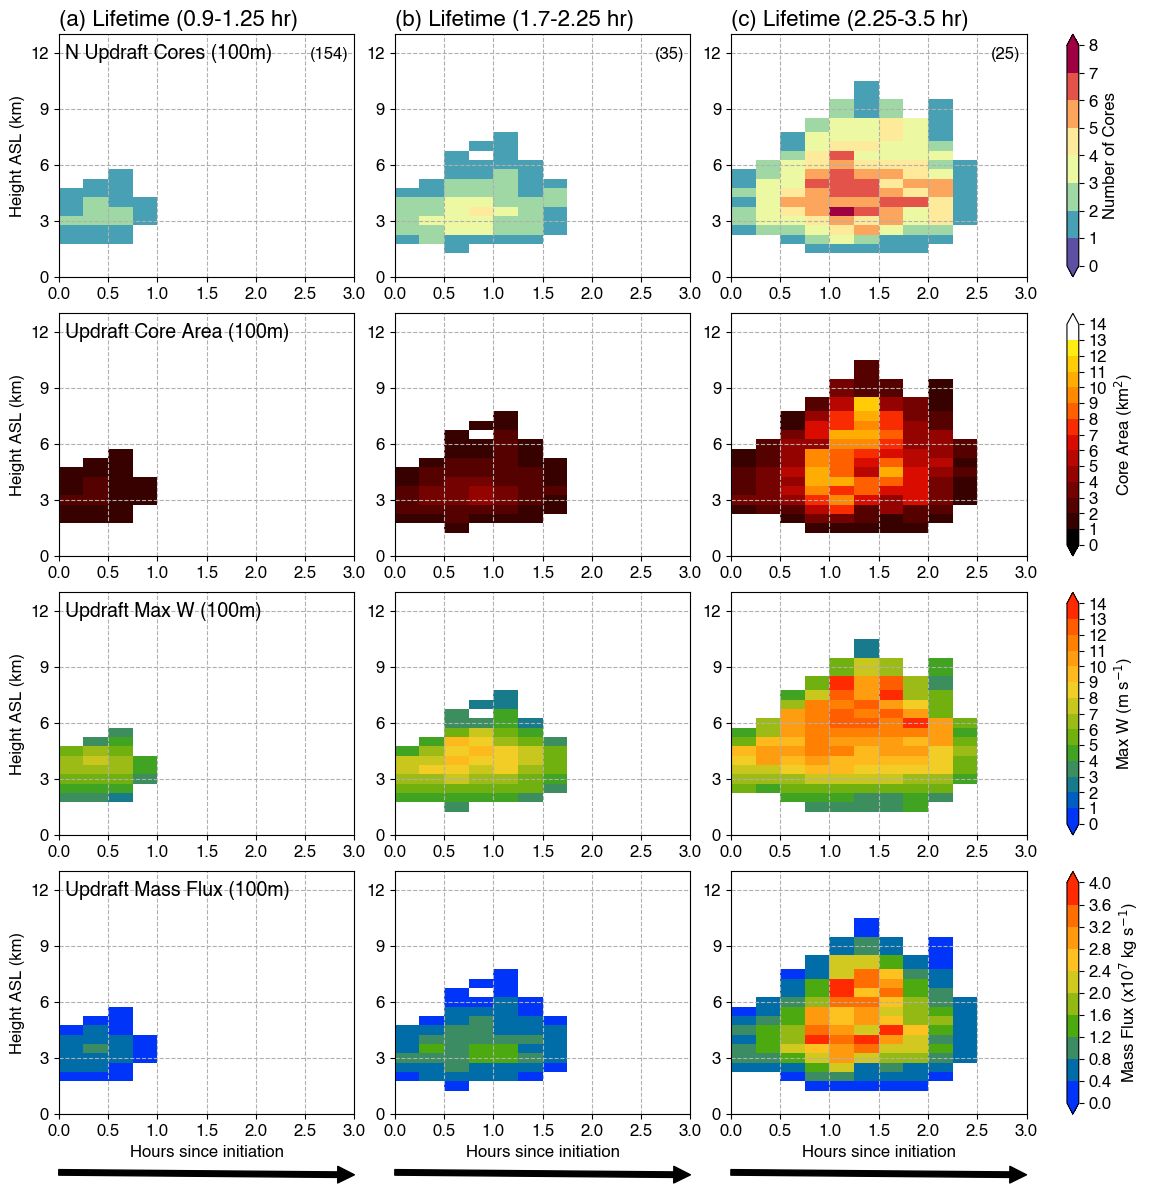

In [149]:
times_hour = ds_d4.times * time_res_d4 + time_res_d4/2
legend1 = [f'N Updraft Cores ({gridspacing_d4})', f'Updraft Core Area ({gridspacing_d4})', f'Updraft Max W ({gridspacing_d4})', f'Updraft Mass Flux ({gridspacing_d4})']
legend2 = [
    [f'({ntracks2_Up_d4})', f'({ntracks3_Up_d4})', f'({ntracks4_Up_d4})'],
    ['', '', ''],
]
qntl = 0.5
MFpower = 7
MFscale = 10**MFpower
dataarr = [
    [nCoreUp2_d4.where(nCoreUp2_d4 > 0).sel(quantile=qntl).transpose(),
     nCoreUp3_d4.where(nCoreUp3_d4 > 0).sel(quantile=qntl).transpose(),
     nCoreUp4_d4.where(nCoreUp4_d4 > 0).sel(quantile=qntl).transpose(),],
    [CoreAreaUp2_d4.where(CoreAreaUp2_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp3_d4.where(CoreAreaUp3_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp4_d4.where(CoreAreaUp4_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMaxWUp2_d4.where(CoreMaxWUp2_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp3_d4.where(CoreMaxWUp3_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp4_d4.where(CoreMaxWUp4_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [MassFluxUp2_d4.where(MassFluxUp2_d4 > 0).sel(quantile=qntl).isel(core=0).transpose()/MFscale,
     MassFluxUp3_d4.where(MassFluxUp3_d4 > 0).sel(quantile=qntl).isel(core=0).transpose()/MFscale,
     MassFluxUp4_d4.where(MassFluxUp4_d4 > 0).sel(quantile=qntl).isel(core=0).transpose()/MFscale,],
]
lev_nCore = np.arange(0, 8.1, 1)
lev_CoreArea = np.arange(0, 14.1, 1)
lev_CoreMaxW = np.arange(0, 14.1, 1)
lev_MassFlux = np.arange(0, 4.01, 0.4)
levels = [lev_nCore, lev_CoreArea, lev_CoreMaxW, lev_MassFlux]
cbticks = levels
cmaps = ['Spectral_r', cc.cm['fire'], cc.cm['rainbow'], cc.cm['rainbow']]
cblabel = ['Number of Cores', 'Core Area (km$^2$)', 'Max W (m s$^{-1}$)', f'Mass Flux (x10$^{MFpower}$ '+'kg s$^{-1}$)']
xlims = (0, 3.0)
ylims = (0, 13)
xticks = np.arange(0, 3.01, 0.5)
yticks = np.arange(0, 12.1, 3)
xlabels = 'Hours since initiation'
titles = [f'(a) Lifetime ({lifetime_range2[0]}-{lifetime_range2[1]} hr)', 
          f'(b) Lifetime ({lifetime_range3[0]}-{lifetime_range3[1]} hr)', 
          f'(c) Lifetime ({lifetime_range4[0]}-{lifetime_range4[1]} hr)']
figname = f'{figdir}celltrack_composite_updraft_profile_evolution_{qntl*100:.0f}quantile_d4.png'
fig = plot_timeheight_Nvars(times_hour, HAMSL_d4/1000, dataarr, levels, cmaps, xlims, ylims, xlabels, xticks, yticks, titles, cblabel, cbticks, legend1, legend2, figname, 
                            figsize=[12,12])

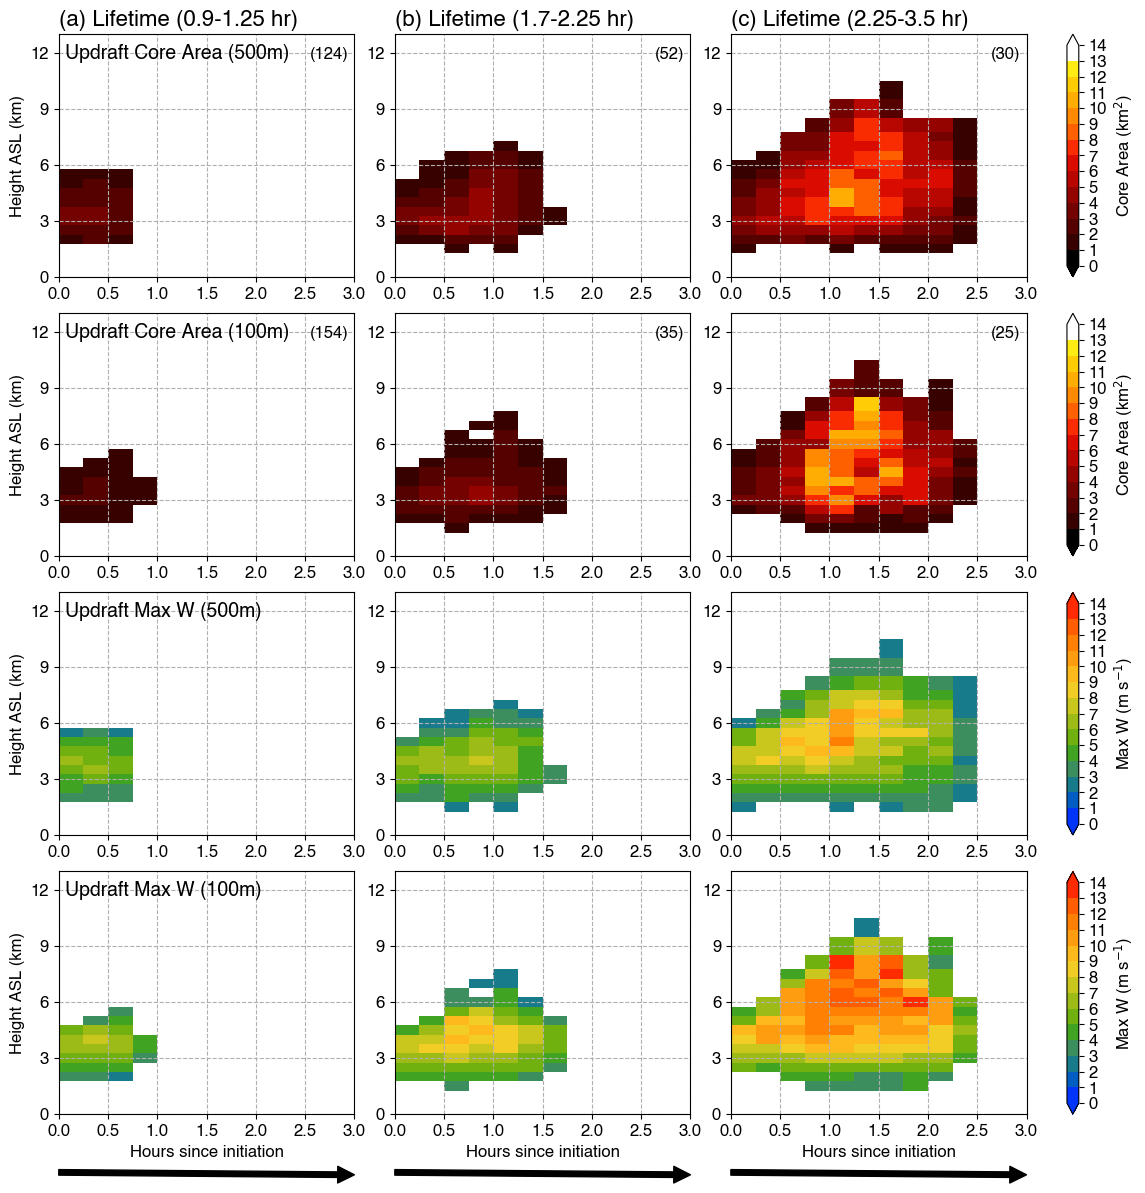

In [150]:
times_hour = ds_d3.times * time_res_d3 + time_res_d3/2
legend1 = [f'Updraft Core Area ({gridspacing_d3})', f'Updraft Core Area ({gridspacing_d4})', f'Updraft Max W ({gridspacing_d3})', f'Updraft Max W ({gridspacing_d4})']
legend2 = [
    [f'({ntracks2_Up_d3})', f'({ntracks3_Up_d3})', f'({ntracks4_Up_d3})'],
    [f'({ntracks2_Up_d4})', f'({ntracks3_Up_d4})', f'({ntracks4_Up_d4})'],
]
qntl = 0.5
MFpower = 7
MFscale = 10**MFpower
dataarr = [
    [CoreAreaUp2_d3.where(CoreAreaUp2_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp3_d3.where(CoreAreaUp3_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp4_d3.where(CoreAreaUp4_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreAreaUp2_d4.where(CoreAreaUp2_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp3_d4.where(CoreAreaUp3_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp4_d4.where(CoreAreaUp4_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMaxWUp2_d3.where(CoreMaxWUp2_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp3_d3.where(CoreMaxWUp3_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp4_d3.where(CoreMaxWUp4_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMaxWUp2_d4.where(CoreMaxWUp2_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp3_d4.where(CoreMaxWUp3_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp4_d4.where(CoreMaxWUp4_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
]
lev_CoreArea = np.arange(0, 14.1, 1)
lev_CoreMaxW = np.arange(0, 14.1, 1)
levels = [lev_CoreArea, lev_CoreArea, lev_CoreMaxW, lev_CoreMaxW]
cbticks = levels
cmaps = [cc.cm['fire'], cc.cm['fire'], cc.cm['rainbow'], cc.cm['rainbow'],]
cblabel = ['Core Area (km$^2$)', 'Core Area (km$^2$)', 'Max W (m s$^{-1}$)', 'Max W (m s$^{-1}$)',]
xlims = (0, 3.0)
ylims = (0, 13)
xticks = np.arange(0, 3.01, 0.5)
yticks = np.arange(0, 12.1, 3)
xlabels = 'Hours since initiation'
titles = [f'(a) Lifetime ({lifetime_range2[0]}-{lifetime_range2[1]} hr)', 
          f'(b) Lifetime ({lifetime_range3[0]}-{lifetime_range3[1]} hr)', 
          f'(c) Lifetime ({lifetime_range4[0]}-{lifetime_range4[1]} hr)']
figname = f'{figdir}celltrack_composite_updraft_profile_evolution_{qntl*100:.0f}quantile_d3_d4.png'
fig = plot_timeheight_Nvars(times_hour, HAMSL_d3/1000, dataarr, levels, cmaps, xlims, ylims, xlabels, xticks, yticks, titles, cblabel, cbticks, legend1, legend2, figname, 
                            figsize=[12,12], )

In [151]:
# CoreMinWDn2_d3.where(CoreMinWDn2_d3 < 0).sel(quantile=qntl).isel(core=0).transpose().plot()

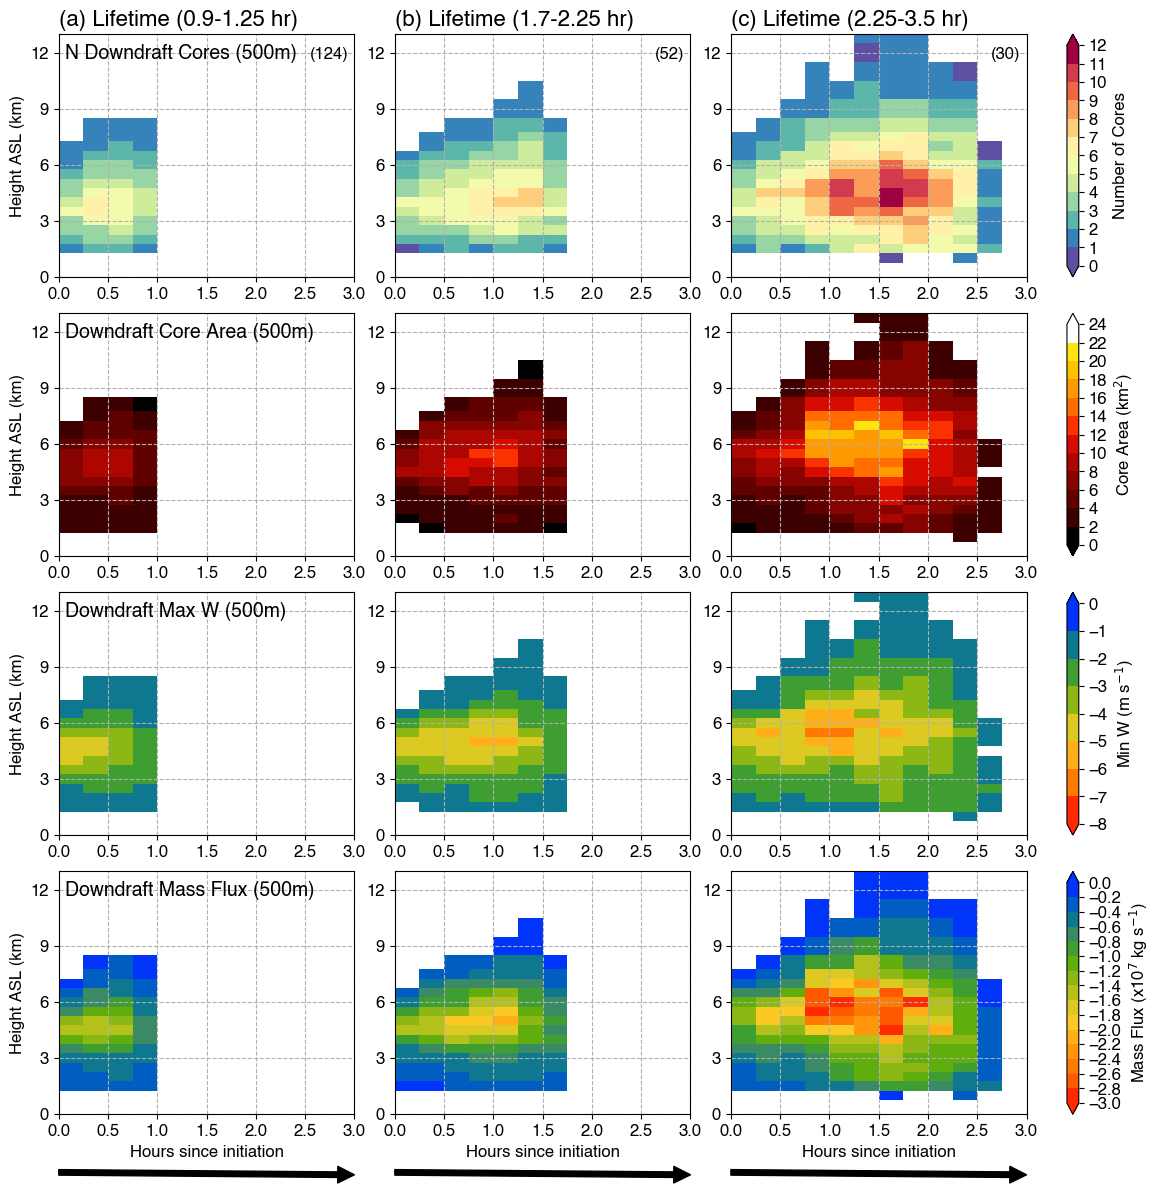

In [152]:
times_hour = ds_d3.times * time_res_d3 + time_res_d3/2
legend1 = [f'N Downdraft Cores ({gridspacing_d3})', f'Downdraft Core Area ({gridspacing_d3})', f'Downdraft Max W ({gridspacing_d3})', f'Downdraft Mass Flux ({gridspacing_d3})']
legend2 = [
    [f'({ntracks2_Dn_d3})', f'({ntracks3_Dn_d3})', f'({ntracks4_Dn_d3})'],
    ['', '', ''],
]
qntl = 0.5
MFpower = 7
MFscale = 10**MFpower
dataarr = [
    [nCoreDn2_d3.where(nCoreDn2_d3 > 0).sel(quantile=qntl).transpose(),
     nCoreDn3_d3.where(nCoreDn3_d3 > 0).sel(quantile=qntl).transpose(),
     nCoreDn4_d3.where(nCoreDn4_d3 > 0).sel(quantile=qntl).transpose(),],
    [CoreAreaDn2_d3.where(CoreAreaDn2_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaDn3_d3.where(CoreAreaDn3_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaDn4_d3.where(CoreAreaDn4_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMinWDn2_d3.where(CoreMinWDn2_d3 < 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMinWDn3_d3.where(CoreMinWDn3_d3 < 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMinWDn4_d3.where(CoreMinWDn4_d3 < 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [MassFluxDn2_d3.where(MassFluxDn2_d3 < 0).sel(quantile=qntl).isel(core=0).transpose()/MFscale,
     MassFluxDn3_d3.where(MassFluxDn3_d3 < 0).sel(quantile=qntl).isel(core=0).transpose()/MFscale,
     MassFluxDn4_d3.where(MassFluxDn4_d3 < 0).sel(quantile=qntl).isel(core=0).transpose()/MFscale,],
]
lev_nCore = np.arange(0, 12.1, 1)
lev_CoreArea = np.arange(0, 24.1, 2)
lev_CoreMaxW = np.arange(-8, 0.1, 1)
lev_MassFlux = np.arange(-3.0, 0.01, 0.2)
levels = [lev_nCore, lev_CoreArea, lev_CoreMaxW, lev_MassFlux]
cbticks = levels
cmaps = ['Spectral_r', cc.cm['fire'], cc.cm['rainbow_r'], cc.cm['rainbow_r']]
cblabel = ['Number of Cores', 'Core Area (km$^2$)', 'Min W (m s$^{-1}$)', f'Mass Flux (x10$^{MFpower}$ '+'kg s$^{-1}$)']
xlims = (0, 3.0)
ylims = (0, 13)
xticks = np.arange(0, 3.01, 0.5)
yticks = np.arange(0, 12.1, 3)
xlabels = 'Hours since initiation'
titles = [f'(a) Lifetime ({lifetime_range2[0]}-{lifetime_range2[1]} hr)', 
          f'(b) Lifetime ({lifetime_range3[0]}-{lifetime_range3[1]} hr)', 
          f'(c) Lifetime ({lifetime_range4[0]}-{lifetime_range4[1]} hr)']
figname = f'{figdir}celltrack_composite_downdraft_profile_evolution_{qntl*100:.0f}quantile_d3.png'
fig = plot_timeheight_Nvars(times_hour, HAMSL_d3/1000, dataarr, levels, cmaps, xlims, ylims, xlabels, xticks, yticks, titles, cblabel, cbticks, legend1, legend2, figname, 
                            figsize=[12,12])

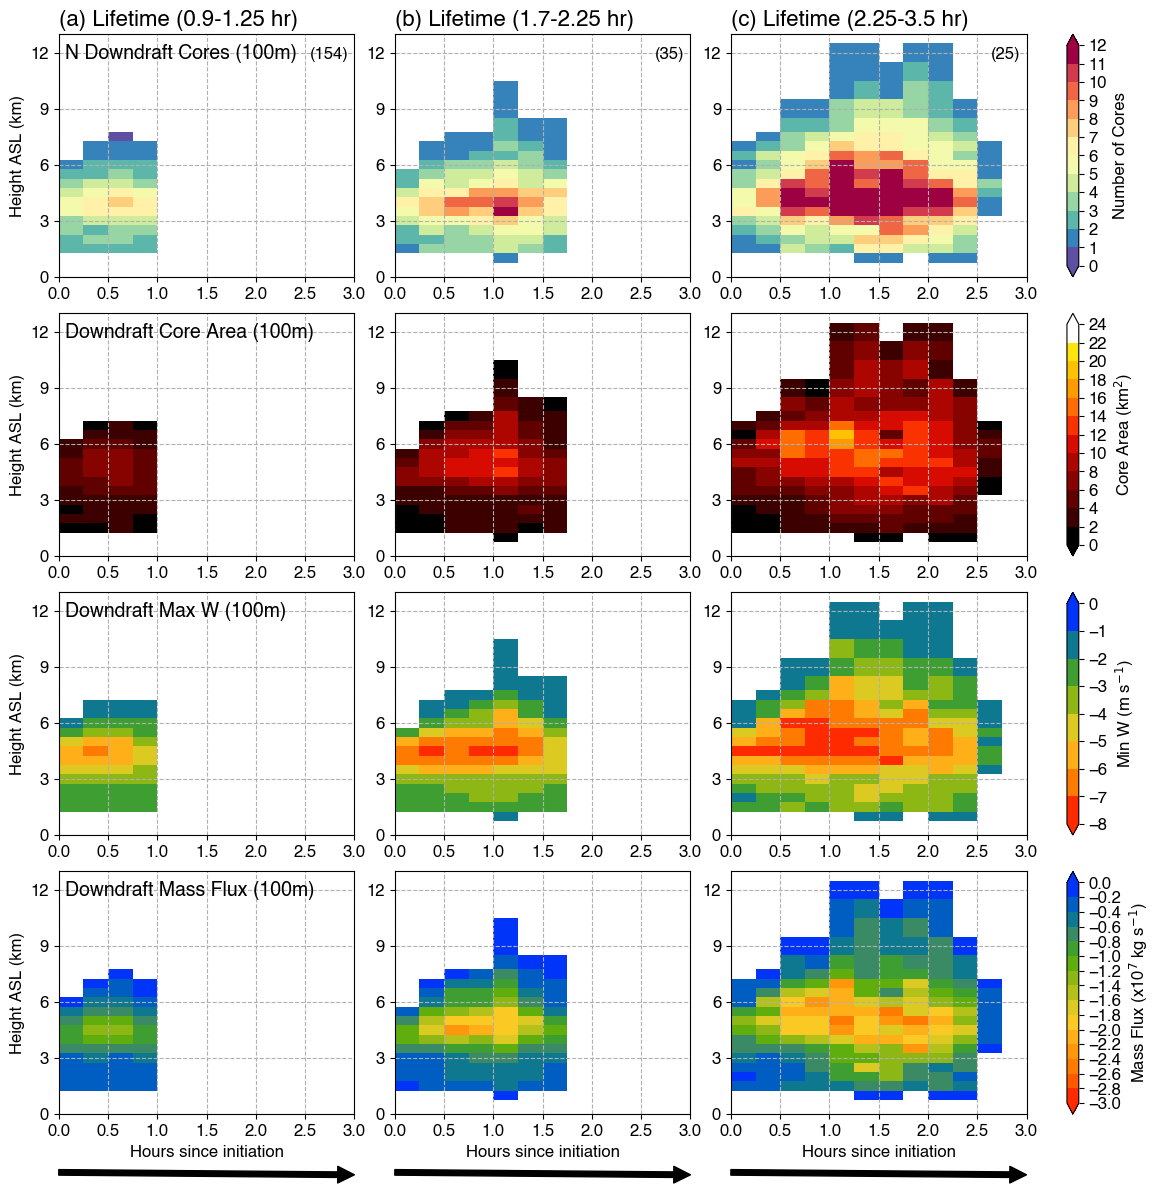

In [153]:
times_hour = ds_d4.times * time_res_d4 + time_res_d4/2
legend1 = [f'N Downdraft Cores ({gridspacing_d4})', f'Downdraft Core Area ({gridspacing_d4})', f'Downdraft Max W ({gridspacing_d4})', f'Downdraft Mass Flux ({gridspacing_d4})']
legend2 = [
    [f'({ntracks2_Dn_d4})', f'({ntracks3_Dn_d4})', f'({ntracks4_Dn_d4})'],
    ['', '', ''],
]
qntl = 0.5
MFpower = 7
MFscale = 10**MFpower
dataarr = [
    [nCoreDn2_d4.where(nCoreDn2_d4 > 0).sel(quantile=qntl).transpose(),
     nCoreDn3_d4.where(nCoreDn3_d4 > 0).sel(quantile=qntl).transpose(),
     nCoreDn4_d4.where(nCoreDn4_d4 > 0).sel(quantile=qntl).transpose(),],
    [CoreAreaDn2_d4.where(CoreAreaDn2_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaDn3_d4.where(CoreAreaDn3_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaDn4_d4.where(CoreAreaDn4_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMinWDn2_d4.where(CoreMinWDn2_d4 < 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMinWDn3_d4.where(CoreMinWDn3_d4 < 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMinWDn4_d4.where(CoreMinWDn4_d4 < 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [MassFluxDn2_d4.where(MassFluxDn2_d4 < 0).sel(quantile=qntl).isel(core=0).transpose()/MFscale,
     MassFluxDn3_d4.where(MassFluxDn3_d4 < 0).sel(quantile=qntl).isel(core=0).transpose()/MFscale,
     MassFluxDn4_d4.where(MassFluxDn4_d4 < 0).sel(quantile=qntl).isel(core=0).transpose()/MFscale,],
]
lev_nCore = np.arange(0, 12.1, 1)
lev_CoreArea = np.arange(0, 24.1, 2)
lev_CoreMaxW = np.arange(-8, 0.1, 1)
lev_MassFlux = np.arange(-3.0, 0.01, 0.2)
levels = [lev_nCore, lev_CoreArea, lev_CoreMaxW, lev_MassFlux]
cbticks = levels
cmaps = ['Spectral_r', cc.cm['fire'], cc.cm['rainbow_r'], cc.cm['rainbow_r']]
cblabel = ['Number of Cores', 'Core Area (km$^2$)', 'Min W (m s$^{-1}$)', f'Mass Flux (x10$^{MFpower}$ '+'kg s$^{-1}$)']
xlims = (0, 3.0)
ylims = (0, 13)
xticks = np.arange(0, 3.01, 0.5)
yticks = np.arange(0, 12.1, 3)
xlabels = 'Hours since initiation'
titles = [f'(a) Lifetime ({lifetime_range2[0]}-{lifetime_range2[1]} hr)', 
          f'(b) Lifetime ({lifetime_range3[0]}-{lifetime_range3[1]} hr)', 
          f'(c) Lifetime ({lifetime_range4[0]}-{lifetime_range4[1]} hr)']
figname = f'{figdir}celltrack_composite_downdraft_profile_evolution_{qntl*100:.0f}quantile_d4.png'
fig = plot_timeheight_Nvars(times_hour, HAMSL_d4/1000, dataarr, levels, cmaps, xlims, ylims, xlabels, xticks, yticks, titles, cblabel, cbticks, legend1, legend2, figname, 
                            figsize=[12,12])

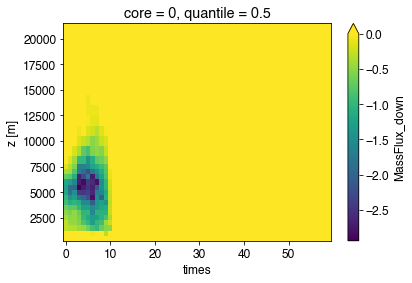

In [65]:
(MassFluxDn4_d3/1e7).sel(quantile=qntl).isel(core=0).transpose().plot(vmax=0)

In [45]:
figdir

'/gpfs/wolf/cli120/proj-shared/zfeng/cacti/pyflextrkr_paper/'

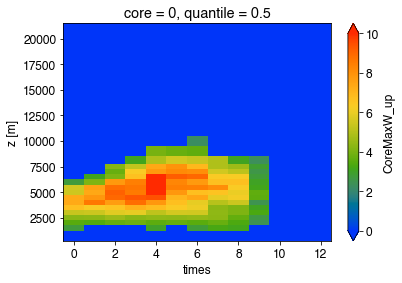

In [46]:
qntl = 0.5
CoreMaxWUp4_d3.sel(quantile=qntl).isel(core=0, times=slice(0,13)).transpose().plot(vmin=0, vmax=10, cmap=cc.cm['rainbow'])

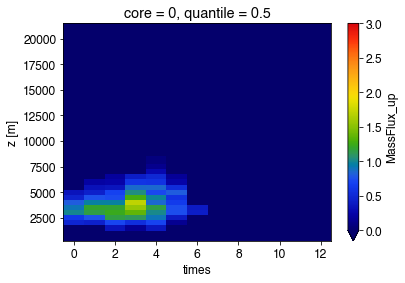

In [47]:
(MassFluxUp3_d3/MFscale).sel(quantile=qntl).isel(core=0, times=slice(0,13)).transpose().plot(vmin=0, vmax=3, cmap=cc.cm['rainbow4'])